In [1]:
import numpy as np
import matplotlib.pyplot as plt
from astropy.modeling.models import BlackBody
from astropy import units as u
from astropy import constants as const

In [2]:
### FUNCTIONS

def luminosity_bb(T, lambda_1, lambda_2):
    """
    Determines the blackbody flux integrated over some wavelength range

    :param T: the temperature (effective temperature for the star, dayside temperature for the planet) (in Kelvin)
    :type T: float

    :param lambda_1: the lower wavelength bound (in microns)
    :type lambda_1: float

    :param lambda_2: the upper wavelength bound (in microns)
    :type lambda_2: float

    :return: integrated flux
    :rtype: np.array
    """

    bb = BlackBody(temperature=T*u.K)
    wav = np.arange(lambda_1, lambda_2, 0.05) * u.micron
    flux = bb(wav)
    return np.trapezoid(flux)

def phase_planet(t,P,t0=0):
    """
    Determines the phase of a planet at a given time.

    :param t: the time (in days)
    :type t: float

    :param P: the orbital period (in days)
    :type P: float

    :param t0: the reference time (in days)
    :type t0: float

    :return: phase
    :rtype: float
    """

    phase = np.sin(((t+t0)/P)*2*np.pi - np.pi/2)/2+0.5 # equation 15
    return phase

def phase_curve(L_star, L_planet, R_star, R_planet, phase_planet, eclipse, transit_depth, transit):
    """
    Determines the phase curve of a planet from its luminosity, its star's luminosity and its phase function expressed as the ratio between the planet and star's luminosities in ppm.

    :param L_star: the star luminosity (in W)
    :type L_star: float

    :param L_planet: the planet luminosity (in W)
    :type L_planet: float

    :param R_star: the star radius (in m)
    :type R_star: float

    :param R_planet: the planet radius (in m)
    :type R_planet: float

    :param phase_planet: the phase function of the planet
    :type phase_planet: float

    :param eclipse: True if the planet is in eclipse, False otherwise
    :type eclipse: bool

    :return: curve
    :rtype: float
    """
    
    curve = (L_planet/L_star)*phase_planet*(R_planet/R_star)**2 * (-1*eclipse+1) + 1 -transit_depth*transit # *10**6 to have in ppm
    return curve

def transit_depth(R_planet, R_star):
    """
    Determines the depth of an exoplanet transit.

    :param R_planet: the radius of the planet (in m)
    :type Rp: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :return: delta_F
    :rtype: float
    """

    delta_F = (R_planet/R_star)**2
    return delta_F

def transit_impact_parameter(a, i, e, R_star, omega):
    """
    Determines the impact parameter of an exoplanet transit.

    :param a: the semimajor axis (in m)
    :type a: float

    :param i: the inclination (in rad)
    :type i: float

    :param e: the eccentricity
    :type e: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :param omega: the argument of pericentre (in rad)
    :type omega: float

    :return: b
    :rtype: float
    """

    b = a/R_star * np.cos(i) * (1-e**2)/(1+e*np.sin(omega))
    return b

def eclipse_impact_parameter(a, i, e, R_star, omega):
    """
    Determines the impact parameter of an exoplanet eclipse.

    :param a: the semimajor axis (in m)
    :type a: float

    :param i: the inclination (in rad)
    :type i: float

    :param e: the eccentricity
    :type e: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :param omega: the argument of pericentre (in rad)
    :type omega: float

    :return: b
    :rtype: float
    """

    b = a/R_star * np.cos(i) * (1-e**2)/(1-e*np.sin(omega))
    return b

def total_transit_duration(P, a, R_star, R_planet, i, e, omega, b):
    """
    Determines the total duration of an exoplanet transit (in s).

    :param P: the orbital period (in s)
    :type P: float

    :param a: the semimajor axis (in m)
    :type a: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :param R_planet: the radius of the planet (in m)
    :type R_planet: float

    :param i: the inclination (in rad)
    :type i: float

    :param e: the eccentricity
    :type e: float

    :param omega: the argument of pericentre (in rad)
    :type omega: float

    :param b: the transit impact parameter
    :type b: float

    :return: t_total
    :rtype: float
    """

    t_total = P/np.pi * np.arcsin(R_star/a * np.sqrt(((1+R_planet/R_star)**2 - (a/R_star * np.cos(i))**2) / (1-np.cos(i)**2)))

    return t_total

def eclipse(P, a, R_star, R_planet, i, phase, e, omega, b, t):
    """
    Determines if an exoplanet is in eclipse or not at a given phase.

    :param P: the orbital period (in s)
    :type P: float

    :param a: the semimajor axis (in m)
    :type a: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :param R_planet: the radius of the planet (in m)
    :type R_planet: float

    :param i: the inclination (in rad)
    :type i: float

    :param phase: the phase of the exoplanet (in rad)
    :type phase: function

    :param e: the eccentricity
    :type e: float

    :param omega: the argument of pericentre (in rad)
    :type omega: float

    :param b: the impact parameter
    :type b: float

    :return: in_eclipse
    :rtype: bool
    """

    t_eclipse = total_transit_duration(P, a, R_star, R_planet, i, e, omega, b)

    return phase(t, P) > 1 - phase(t_eclipse/2, P)

def transit(P, a, R_star, R_planet, i, phase, e, omega, b, t):
    """
    Determines if an exoplanet is in transit or not at a given phase.

    :param P: the orbital period (in s)
    :type P: float

    :param a: the semimajor axis (in m)
    :type a: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :param R_planet: the radius of the planet (in m)
    :type R_planet: float

    :param i: the inclination (in rad)
    :type i: float

    :param phase: the phase of the exoplanet (in rad)
    :type phase: function

    :param e: the eccentricity
    :type e: float

    :param omega: the argument of pericentre (in rad)
    :type omega: float

    :param b: the impact parameter
    :type b: float

    :return: in_eclipse
    :rtype: bool
    """

    t_eclipse = total_transit_duration(P, a, R_star, R_planet, i, e, omega, b)

    return phase(t, P) < phase(t_eclipse/2, P)

## Temperature of the planet in terms of the temperature of the star and the distance to it

In [3]:
def planet_temperature(T_star, R_star, a, albedo):
    """
    Determines the temperature of the planet assuming circular orbit.
    The albedo is determined by choosing the "type of planet"

    :param T_star: temperature of the star (in K) 
    :type T_star: float

    :param R_star: radius of the star (in m) 
    :type R_star: float

    :param a: the semimajor axis (in m)
    :type a: float

    :param albedo: albedo (dimensionless)
    :type albedo: float

    :return: T_planet
    :rtype: float
    """

    T_planet = T_star * ((R_star / a) ** 0.5) * ((1-albedo) / 4)**0.25

    return T_planet

In [4]:
T_star = 5778
R_star = const.R_sun.value
a = const.au.value
albedo = 0.3
print("The surface temperature of the Sun is", T_star, "K and the surface temperature of the Earth is", planet_temperature(T_star, R_star, a, albedo), "K.")

The surface temperature of the Sun is 5778 K and the surface temperature of the Earth is 254.85041511888895 K.


## First simulation of an atmosphere

In [5]:
def surface_gravity(M_p, R_p):
    """
    Determines surface gravity of the planet (in ms-2)

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :return: g
    :rtype: float
    
    """

    g = const.G.value * M_p / R_p**2

    return g

def scale_height(T_atm, Mm, M_p, R_p):
    """
    Determines the scale height of the atmosphere (in m) 

    :param T_atm: temperature of the atmosphere (in K) 
    :type T_atm: float

    :param Mm: molecular mass (g/mol)
    :type Mm: float

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :return: H
    :rtype: float
    """
    g = surface_gravity(M_p, R_p)
    H = (const.k_B.value * T_atm) / (Mm*const.m_p.value * g)

    return H

def surface_number_density(P0, T_atm):
    """
    Determines surface number density with ideal gas law (in m-3)

    :param P0: pressure of the atmosphere (in Pa) 
    :type P0: float

    :param T_atm: temperature of the atmosphere (in K) 
    :type T_atm: float

    :return: n0 the number density (molecules/m^3)
    :rtype: float
    """
    n0 = (P0 / (const.k_B.value * T_atm))

    return n0

def absorption_cross_section(centre, width, sigma0, wavelength):
    """
    Determines absorption cross section assuming a gaussian centered at a particular wavelength (in m2) 

    :param centre: central wavelength (in microns) 
    :type centre: float

    :param width: width of the gaussian (dimensionless)
    :type width: float

    :param sigma0: value for the central absorption cross section (in m2)
    :type sigma0: float

    :param wavelength: wavelength (in microns)
    :type width: float
    
    :return: sigma_lambda
    :rtype: float
    """
    sigma_lambda = sigma0 * np.exp(- ((wavelength - centre) / width)**2)

    return sigma_lambda

def altitude_tau_1(sigma_lambda, n0, R_p, H):
    """
    Determines the altitude z where tau is 1 (in m)

    :param sigma_lambda: absorption cross section (m2)
    :type centre: float

    :param n0: surface number density with ideal gas law (in m-3)
    :type width: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param H: scale height of the atmosphere (in m) 
    :type width: float
    
    :return: z_tau1
    :rtype: float
    """
    
    inside_log = (sigma_lambda * n0 * np.sqrt(2 * np.pi * R_p * H))
    #Important note, if the value inside_log is smaller than one, then the value of altitude_tau_1 would be negative
    #We could study that case separatly and just say that in that case the atmosphere is optically thin and make z=0 for example
    #I am not including that case in this first version. 
    z_tau1 = H * np.log(inside_log)

    return z_tau1

def eff_radius_planet(R_p, z_tau1):
    """
    Determines the effective radius of the planet with atmosphere (in m) 

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param z_tau1: the altitude z where tau is 1 (in m) 
    :type z_tau1: float

    :return: R_eff
    :rtype: float
    
    """
    
    R_eff = R_p + z_tau1

    return R_eff
    
def transit_depth_lambda(R_eff, R_star):
    """
    Determines the wavelength-dependent depth of an exoplanet transit.

    :param R_eff: the effective radius of the planet with atmosphere (in m)
    :type Rp: float

    :param R_star: the radius of the star (in m)
    :type R_star: float

    :return: delta_lambda
    :rtype: float
    """

    delta_lambda = (R_eff / R_star)**2
    return delta_lambda

In [6]:
print(const.R)

  Name   = Gas constant
  Value  = 8.31446261815324
  Uncertainty  = 0.0
  Unit  = J / (K mol)
  Reference = CODATA 2018


## Density profile in the atmosphere

In [7]:
def density_profile_atm_consT(z, T_atm, H, P0, fraction=1):
    """
    Determines the density profile (in m-3) of a certain species in the atmosphere based on simple hydrostatic equilibrium + ideal gas law.
    This function assumes constant temperature T(z)=T_atm.

    :param z: height above the surface (in m)
    :type z: float
    
    :param T_atm: temperature of the atmosphere assumed constant (in K) 
    :type T_atm: float

    :param Mm: molecular mass (g/mol)
    :type Mm: float


    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param P0: pressure of the atmosphere (in Pa) 
    :type P0: float

    :return: n
    :rtype: float
    
    """
    n0 = surface_number_density(P0, T_atm)*fraction

    n = n0 * np.exp(-z/H)

    return n

def density_profile_atm_linearT(z, T_atm_0, Mm, M_p, R_p, P0, constant):
    """
    Determines the density profile (in m-3) of a certain species in the atmosphere based on simple hydrostatic equilibrium + ideal gas law.
    This function assumes a temperature T(z) = T_atm_0 - constant * z. 

    :param T_atm_0: temperature of the atmosphere at the surface (in K) 
    :type T_atm_0: float

    :param Mm: molecular mass (g/mol)
    :type Mm: float

    :param M_p: mass of the planet (in kg) 
    :type M_p: float

    :param R_p: radius of the planet (in m) 
    :type R_p: float

    :param P0: pressure of the atmosphere (in Pa) 
    :type P0: float

    :param constant: constant in the linear expression (in K/m)
    :type constnat: float

    :return: n
    :rtype: float
    
    """

    T = T_atm_0 - constant * z 
    g = surface_gravity(M_p, R_p)

    n = (P0 / (const.k_B.value * T)) * (1 - constant * z / T_atm_0) ** ((g * (Mm/(1000 * const.N_A.value))) / (constant * const.k_B.value))

    return n


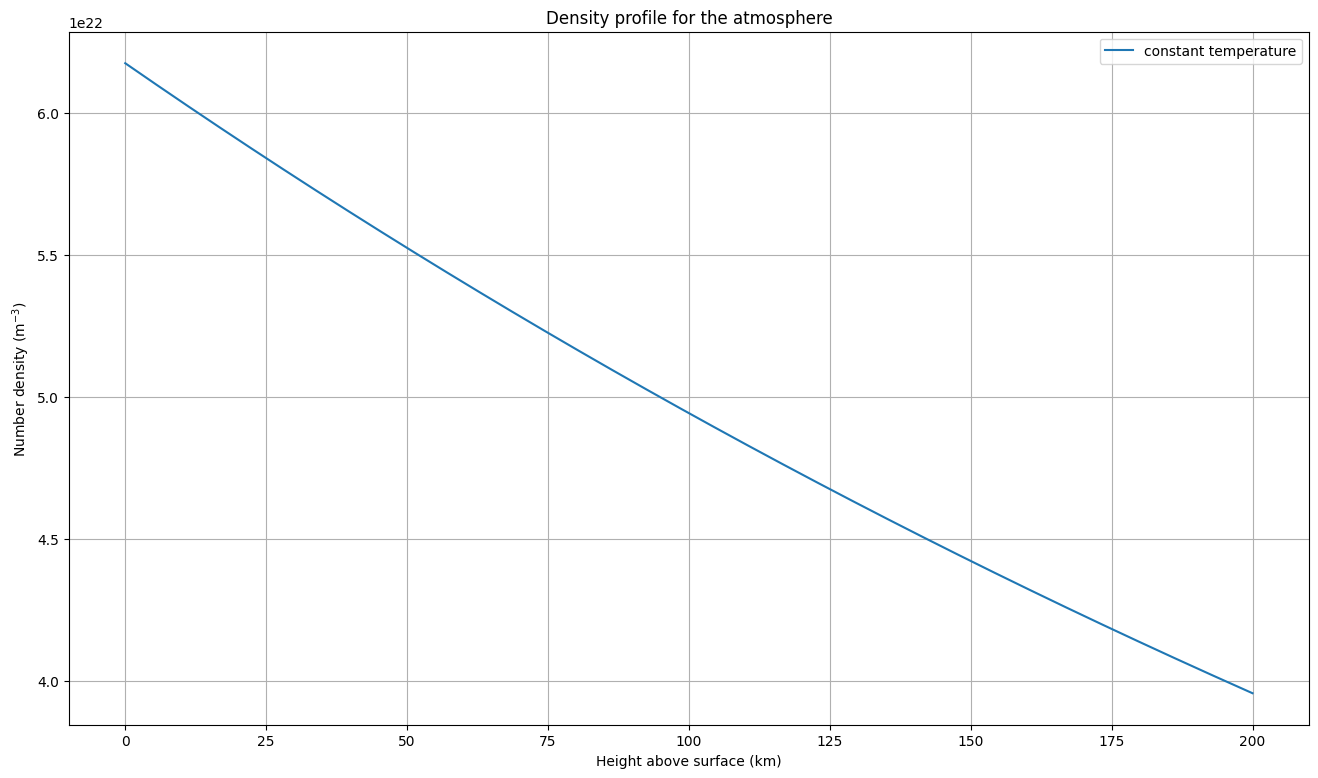

In [8]:
#Test of the density profiles (using data for the WASP-39 b) 
z = np.linspace(0, 200000, num=1000)
T_atm = 900 + 273
Mm = 44 
P0 = 1e3  
M_p = const.M_earth.value 
R_p = const.R_earth.value 
constant = 6.5e-3 
H_factor = 20
H = scale_height(T_atm, Mm, M_p, R_p)*H_factor

plt.figure(figsize=(16,9))
plt.plot(z/1000, density_profile_atm_consT(z, T_atm, H, P0), label='constant temperature')
#plt.plot(z/1000, density_profile_atm_linearT(z, T_atm, Mm, M_p, R_p, P0, constant), label='linearly decreasing temperature')
plt.xlabel("Height above surface (km)")
plt.ylabel("Number density " + r'(m$^{-3}$)')
plt.title("Density profile for the atmosphere")
plt.legend()
plt.grid()
plt.show()


Smooth Transit

In [9]:
def transit_smooth(P, a, R_star, R_planet, i, phase, e, omega, b, t, t_start):
    """
    Gives the fraction of how much the planet is in transit.

    :param P: the orbital period (in s)
    :param a: the semimajor axis (in m)
    :param R_star: the radius of the star (in m)
    :param R_planet: the radius of the planet (in m)
    :param i: the inclination (in rad)
    :param phase: the phase of the exoplanet (in rad)
    :param e: the eccentricity
    :param omega: the argument of pericentre (in rad)
    :param b: the impact parameter
    :t: time array
    :t_start: initial time 

    :return: smooth
    :type smooth: boolean array

    """
    t_full = full_transit_duration(P, a, R_star, R_planet, i, e, omega, b)
    t_total = total_transit_duration(P, a, R_star, R_planet, i, e, omega, b)

    # WRAP t 
    t_rel = ((t - t_start + P / 2) % P) - P / 2 

    t_ingress_start = -t_total / 2
    t_ingress_end = -t_full / 2
    t_egress_start = t_full / 2
    t_egress_end = t_total / 2

    smooth = np.zeros_like(t_rel)

    # Ingress: 
    mask_ingress = (t_rel >= t_ingress_start) & (t_rel <= t_ingress_end)
    smooth[mask_ingress] = (t_rel[mask_ingress] - t_ingress_start) / (t_ingress_end - t_ingress_start)

    # Full transit:
    mask_full = (t_rel > t_ingress_end) & (t_rel < t_egress_start)
    smooth[mask_full] = 1.0

    # Egress:
    mask_egress = (t_rel >= t_egress_start) & (t_rel <= t_egress_end)
    smooth[mask_egress] = 1.0 - (t_rel[mask_egress] - t_egress_start) / (t_egress_end - t_egress_start)

    return smooth
    
def full_transit_duration(P, a, R_star, R_planet, i, e, omega, b):
    """
    Determines the total duration of an exoplanet FULL transit (in s).
    tIII − tII

    :param P: the orbital period (in s)
    :param a: the semimajor axis (in m)
    :param R_star: the radius of the star (in m)
    :type R_star: float
    :param R_planet: the radius of the planet (in m)
    :param i: the inclination (in rad)
    :param e: the eccentricity
    :param omega: the argument of pericentre (in rad)
    :param b: the transit impact parameter
    
    :return: t_total
    :rtype: float
    """

    t_total = P/np.pi * np.arcsin(R_star/a * np.sqrt(((1-R_planet/R_star)**2 - (a/R_star * np.cos(i))**2) / (1-np.cos(i)**2)))

    return t_total

In [10]:
#Parameters of the atmosphere
T_atm = 900.0 + 273
Mm = 44 # mean molecular weight of WASP-39 b which is mostly composed of H2/He                           
P0 = 1e5  
M_p = 0.28 * const.M_jup.value 
R_p = 1.27 * const.R_jup.value 

#g = surface_gravity(M_p, R_p)
H_factor = 20 # factor to increase scale height due to turbulent eddy diffusion
H = scale_height(T_atm, Mm, M_p, R_p)*H_factor
print(H)
n0 = surface_number_density(P0, T_atm)

centre = 6.0
width = 0.12
sigma0 = 1e-26


1022809.3564011973


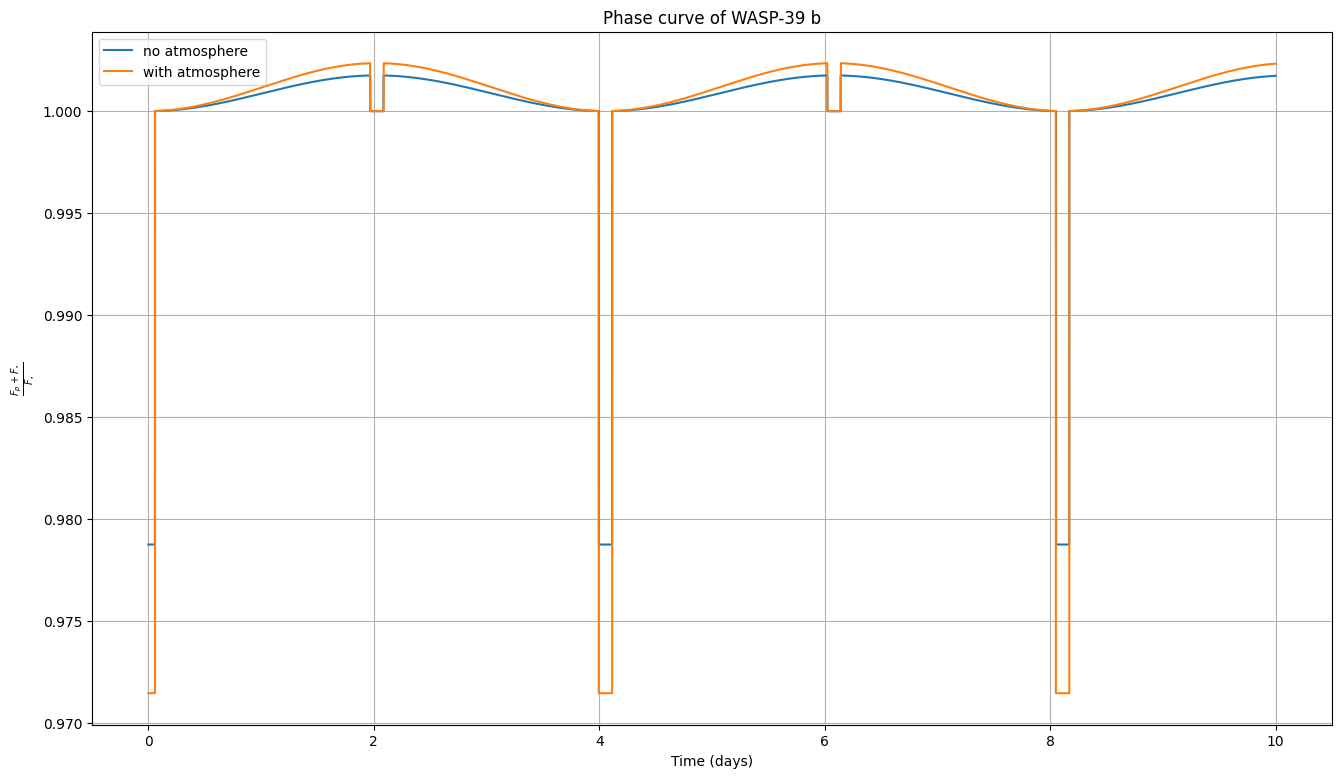

In [11]:
t_start = 0
t_end = 10 # simulation duration in days
nb_points = 10000 # number of points in the time array

t = np.linspace(t_start,t_end,nb_points) # time array in days


# For LHS3844 b, data taken from https://exoplanetarchive.ipac.caltech.edu/overview/LHS%203844%20b#planet_LHS-3844-b_collapsible

e = 0.0
P = 4.055259
omega = 0.0 # bcs e = 0
i = 87.83*np.pi/180
a = 0.0486*149597870700 # a in m
R_star = 0.895*const.R_sun.value
T_star = 5400
T_planet = T_atm
flux_star = BlackBody(T_star*u.K)(5.96*u.micron)
flux_planet = BlackBody(T_planet*u.K)(5.96*u.micron)

#Without atmosphere
phase = phase_planet
b = eclipse_impact_parameter(a,i,e,R_star,omega)
eclipse_bool = eclipse(P,a,R_star,R_p,i,phase,e,omega,b, t)
b = transit_impact_parameter(a,i,e,R_star,omega)
phase_curvee = phase_curve(flux_star,flux_planet,R_star,R_p,phase(t, P),eclipse_bool, transit_depth(R_p, R_star), transit(P, a, R_star, R_p, i, phase, e, omega, b, t))

#With atmosphere

sigma_lambda = absorption_cross_section(centre, width, sigma0, 5.96)
z_tau1 = altitude_tau_1(sigma_lambda, n0, R_p, H)
R_eff = eff_radius_planet(R_p, z_tau1)
delta_lambda = transit_depth_lambda(R_eff, R_star)

b = eclipse_impact_parameter(a,i,e,R_star,omega)
eclipse_bool_atm = eclipse(P,a,R_star,R_eff,i,phase,e,omega,b, t)
b = transit_impact_parameter(a,i,e,R_star,omega)
phase_curve_atm = phase_curve(flux_star,flux_planet,R_star,R_eff,phase(t, P),eclipse_bool_atm, transit_depth_lambda(R_eff, R_star), transit(P, a, R_star, R_eff, i, phase, e, omega, b, t))




plt.figure(figsize=(16,9))
plt.plot(t, phase_curvee, label='no atmosphere')
plt.plot(t, phase_curve_atm, label='with atmosphere')
plt.xlabel("Time (days)")
plt.ylabel(r'$\frac{F_p + F_{\star}}{F_{\star}}$')
plt.title("Phase curve of WASP-39 b")
plt.legend()
plt.grid()
plt.show()

R = R_p

### Test transit_smooth function

t_ingress_start: -0.05855156116162169
t_ingress_end: -0.040452714639286624
t_egress_start: 0.040452714639286624
t_egress_end: 0.05855156116162169
Period: 4.055259


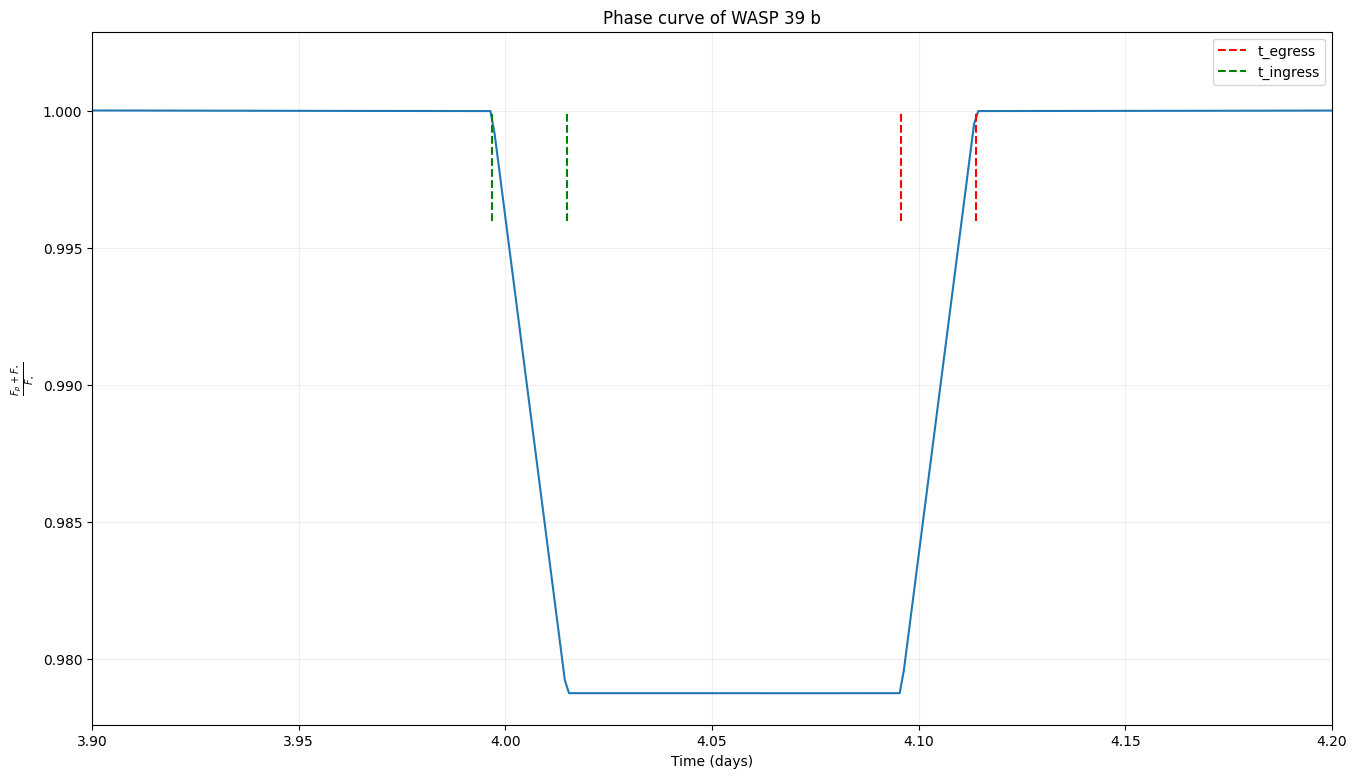

In [12]:
t_full = full_transit_duration(P, a, R_star, R, i, e, omega, b)
t_total = total_transit_duration(P, a, R_star, R, i, e, omega, b)

t_ingress_start = -t_total / 2
t_ingress_end = -t_full / 2
t_egress_start = t_full / 2
t_egress_end = t_total / 2
print("t_ingress_start:", t_ingress_start)
print("t_ingress_end:", t_ingress_end)
print("t_egress_start:", t_egress_start)
print("t_egress_end:", t_egress_end)


print("Period:", P)

t_start = 0
t_end = 10
t = np.linspace(t_start,t_end,nb_points) # time array in days

phase = phase_planet
b = eclipse_impact_parameter(a,i,e,R_star,omega)
eclipse_bool = eclipse(P,a,R_star,R,i,phase,e,omega,b, t)
b = transit_impact_parameter(a,i,e,R_star,omega)
phase_curvee = phase_curve(flux_star,flux_planet,R_star,R,phase(t, P),eclipse_bool, transit_depth(R, R_star), transit_smooth(P, a, R_star, R, i, phase, e, omega, b, t, t_start))


plt.figure(figsize=(16,9))
plt.plot(t, phase_curvee)
plt.plot(np.ones(2)*(t_egress_start + P), [0.996, 1], 'r--', label = "t_egress")
plt.plot(np.ones(2)*(t_egress_end + P), [0.996, 1], 'r--', )

plt.plot(np.ones(2)*(t_ingress_start + P), [0.996, 1], 'g--', label = "t_ingress")
plt.plot(np.ones(2)*(t_ingress_end + P), [0.996, 1], 'g--')

plt.xlabel("Time (days)")
plt.ylabel(r'$\frac{F_p + F_{\star}}{F_{\star}}$')
plt.title("Phase curve of WASP 39 b")

plt.xlim(3.9,4.2)# ZOOM IN

plt.grid(alpha=0.2)
plt.legend()
plt.show()

## INTRODUCING C02

In [13]:
### molecules/atoms : CO2, H2O, O2, H, He
### gases with little/no greenhouse effect : N2, O2, Ar, Ne, He, H2, CO, O3

### Try 1 : CO2

from hapi import * # pip install hapi

# Create or open a local database directory
db_begin('new_hitran_db')

# Fetch CO2 (molecule 2, isotopologue 1) lines for 4.4 µm region
#fetch('CO2_4um', 2, 1, 1800, 3300)   # wavenumbers in cm⁻¹

# The data are stored locally as a table named 'CO2_4um'
# You can load them into a pandas DataFrame:
import pandas as pd
nu, A, elower, g_u, g_l = getColumns('CO2_4um', ['nu', 'A', 'elower', 'gp', 'gpp'])
df = pd.DataFrame({
    'nu': nu,
    'A': A,
    'elower': elower,
    'gp' : g_u,
    'gpp' :g_l
})
print(df.head())


HAPI version: 1.2.2.4
To get the most up-to-date version please check http://hitran.org/hapi
ATTENTION: Python versions of partition sums from TIPS-2021 are now available in HAPI code

           MIT license: Copyright 2021 HITRAN team, see more at http://hitran.org. 

           If you use HAPI in your research or software development,
           please cite it using the following reference:
           R.V. Kochanov, I.E. Gordon, L.S. Rothman, P. Wcislo, C. Hill, J.S. Wilzewski,
           HITRAN Application Programming Interface (HAPI): A comprehensive approach
           to working with spectroscopic data, J. Quant. Spectrosc. Radiat. Transfer 177, 15-30 (2016)
           DOI: 10.1016/j.jqsrt.2016.03.005

           ATTENTION: This is the core version of the HITRAN Application Programming Interface.
                      For more efficient implementation of the absorption coefficient routine, 
                      as well as for new profiles, parameters and other functional,
      

## Small parenthesis: Gaussian, Lorentz and Voigt profiles

In [14]:
#Careful computation of tau_u. For that, I create a df where each row is a transition. 

df_new = df.copy()

# Extract .value from each Quantity in the Series
df_new['elower_val'] = [x for x in df_new['elower']]
df_new['nu_val']     = [x for x in df_new['nu']]

# Compute eupper = elower + nu
df_new['eupper'] = df_new['elower_val'] + df_new['nu_val']

# Compute tau_u
df_new['tau_u'] = 1 / df_new.groupby('eupper')['A'].transform('sum')

#Check that tau_u takes into account ALL A's for which the eupper is indeed an upper level
#I was worried I was not taking all
df_new['1/A'] = 1/df_new['A']

In [15]:
#A print to check
#It seems that the majority of levels are just the upper levels of one transition, so tau_u = 1/A
#But there are some that aren't (see rows 5006 or 5015 for example)
#So this seems to be taking all into account: good
df_new[['nu', 'elower', 'eupper', 'A', 'tau_u', '1/A']].iloc[5000:5020]

,nu,elower,eupper,A,tau_u,1/A
5000,2002.549640,2673.7912,4676.340840,0.000035,28612.303290,28612.303290
5001,2002.575664,941.9736,2944.549264,0.000051,19489.378289,19489.378289
5002,2002.606452,2850.9125,4853.518952,0.000045,22123.893805,22123.893805
5003,2002.606526,1723.5292,3726.135726,0.000041,24497.795198,24497.795198
5004,2002.617428,3259.4946,5262.112028,0.000229,4366.812227,4366.812227
5005,2002.638842,2907.1114,4909.750242,0.047640,20.990764,20.990764
5006,2002.654256,1337.4815,3340.135756,0.000150,312.861746,6653.359947
5007,2002.660086,2583.9197,4586.579786,0.000036,27434.842250,27434.842250
5008,2002.693069,2225.1933,4227.886369,0.000020,50968.399592,50968.399592
5009,2002.697262,3374.9064,5377.603662,0.026330,37.979491,37.979491


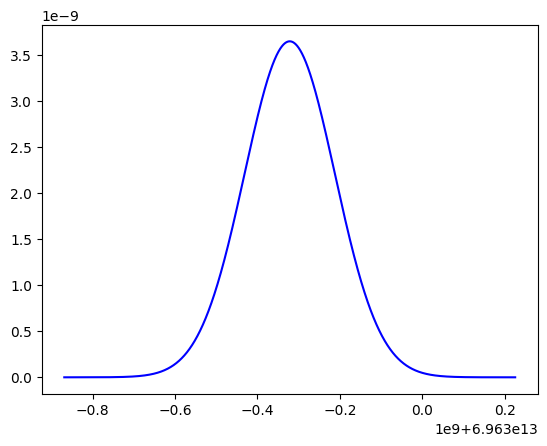

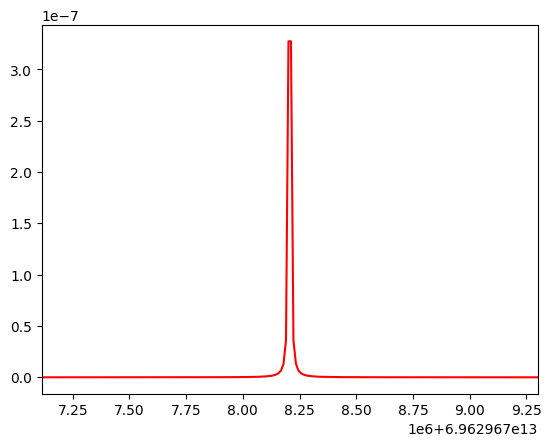

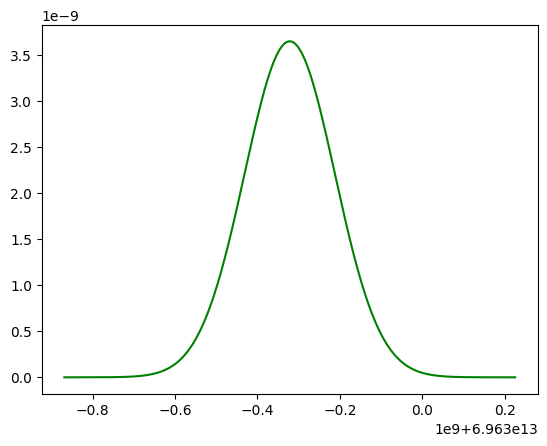

In [16]:
from scipy.special import wofz

# I am creating a new function for the gaussian, I already defined one "absorption_cross_section(centre, width, sigma0, wavelength)"
# but I do not like that it depends on both sigma and width, it is complicated for no reason


def gaussian_profile(sigma,center,frequency):
    return((1/(sigma*np.sqrt(2*np.pi)))* np.exp(-0.5*((frequency-center) / sigma)**2))

def lorentz_profile(delta, center, frequency):
    return delta / (np.pi * ((frequency-center)**2 + delta**2))

def voigt_profile(sigma,delta,center,frequency):
    return((np.real(wofz(((frequency-center) + 1j * delta) / (sigma * np.sqrt(2)))))/ (sigma * np.sqrt(2 * np.pi)))

##General data reading
elower = df['elower'].values*(1/u.cm)
nu = df['nu'].values*(1/u.cm)
eupper = elower + nu
nu = nu.to(u.Hz, equivalencies=u.spectral()) # convert nu in cm-1 to Hz
elower = elower.to(u.J, equivalencies=u.spectral()) # convert energies to J
eupper = eupper.to(u.J, equivalencies=u.spectral())
Mm = 44
tau_lorentz = df_new['tau_u'].values*(u.s)
#freq_array = np.linspace(const.c.value/(5.5*1e-6), const.c.value/(3.0*1e-6), 1000)

for i in range(27806,27807):
    ## For the gaussian (thermal broadening):
    sigma = (nu[i].value/const.c.value)*np.sqrt((const.k_B.value * T_atm) / (Mm/(1000 * const.N_A.value))) #sigma is (nu_0 /c) * sqrt(kT/m)
    center = nu[i].value

    ## For the lorentzian (natural broadening):
    delta = 1/(4 * np.pi * tau_lorentz[i].value)
    
    ## Diagonosing with a couple of plots
    freq_array = np.linspace(center - 5*sigma, center + 5*sigma, 100000)
    
    plt.figure()
    plt.plot(freq_array,gaussian_profile(sigma,center,freq_array),'b')
    plt.show()
    
    plt.figure()
    plt.plot(freq_array,lorentz_profile(delta,center,freq_array),'r')
    plt.xlim(center - 0.01*sigma, center + 0.01*sigma)
    plt.show() 
    
    plt.figure()
    plt.plot(freq_array,voigt_profile(sigma,delta,center,freq_array),'g')
    plt.show()

#Even for some of the bigger values of A, the lorentzian is still a very sharp spike, so the convolution results in something that is basically the same as the gaussian

## Going back to C02

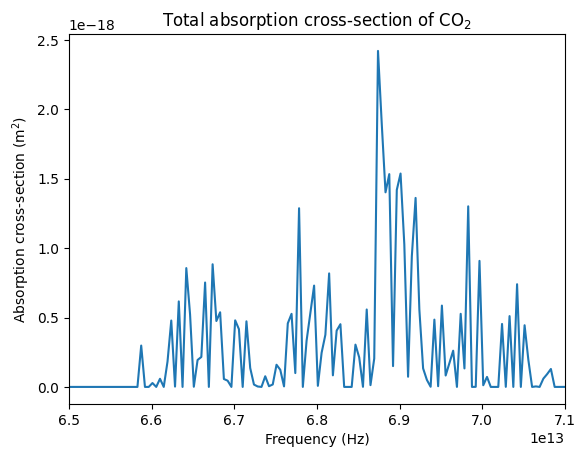

In [17]:
## UNITS : nu = cm-1, A = s-1, elower = cm-1

elower = df['elower'].values*(1/u.cm)
nu = df['nu'].values*(1/u.cm)
eupper = elower + nu
nu = nu.to(u.Hz, equivalencies=u.spectral()) # convert nu in cm-1 to Hz
elower = elower.to(u.J, equivalencies=u.spectral()) # convert energies to J
eupper = eupper.to(u.J, equivalencies=u.spectral())
Mm = 44
tau_lorentz = df_new['tau_u'].values*(u.s)

## computing absorption cross-section

freq_array = np.linspace(const.c.value/(5.5*1e-6), const.c.value/(3.0*1e-6), 1000)
#print(freq_array)
total_absorption_sigma = np.zeros(len(freq_array))

for i in range(len(nu)):
    #width = (nu[i].value/const.c.value)*np.sqrt(2*const.k_B.value*T_atm/(mu*const.m_p.value)) # Doppler broadening due to thermal motion of molecules
    #sigma0 = 1/(np.sqrt(np.pi)*width)
    #gaussian = absorption_cross_section(nu[i].value, width, sigma0, freq_array)
    sigma = (nu[i].value/const.c.value)*np.sqrt((const.k_B.value * T_atm) / (Mm/(1000 * const.N_A.value)))
    center = nu[i].value
    delta = 1/(4 * np.pi * tau_lorentz[i].value)
    
    profile = voigt_profile(sigma,delta,center,freq_array)
    
    #total_absorption_sigma += (df['gp'][i]/df['gpp'][i])*(const.c.value**2/(8*np.pi*nu[i].value**2))*df['A'][i]*gaussian
    total_absorption_sigma += (df['gp'][i]/df['gpp'][i])*(const.c.value**2/(8*np.pi*nu[i].value**2))*df['A'][i]*profile

plt.figure()
plt.plot(freq_array, total_absorption_sigma)
plt.xlabel(r'Frequency (Hz)')
plt.ylabel(r'Absorption cross-section (m$^2$)')
plt.title(r'Total absorption cross-section of CO$_2$')
plt.xlim(0.65*1e14, 0.71*1e14)
plt.show()

In [18]:
#COLLISIONAL BROADENING 
#To include collisional broadening, we need to take into account the height, for it depends on density 
#I repeat the calculation below taking that into account

#IMPORTANT NOTE: this code is not still very optimized, it takes a bit of time to run (1 minute i'd say)
#So careful with increasing the numeber of z points

"""elower = df['elower'].values*(1/u.cm)
nu = df['nu'].values*(1/u.cm)
eupper = elower + nu
nu = nu.to(u.Hz, equivalencies=u.spectral()) # convert nu in cm-1 to Hz
elower = elower.to(u.J, equivalencies=u.spectral()) # convert energies to J
eupper = eupper.to(u.J, equivalencies=u.spectral())
tau_lorentz = df_new['tau_u'].values*(u.s)

##Data that are not in the df's
z_array = np.linspace(0, 2*H, num=50) #I put small num to be faster
T_atm = 900 + 273
Mm_atm = 44 
Mm_CO2 = 44
P0 = 1e6  
M_p = 0.28 * const.M_jup.value 
R_p = 1.27 * const.R_jup.value 
diam_CO2 = 3.3e-10 #kinetic diameter of C02, I got it from https://en.wikipedia.org/wiki/Kinetic_diameter
reduced_mass_CO2_col = 0.5 * (Mm_CO2/(1000 * const.N_A.value))
v_rel_C02 = np.sqrt((8*const.k_B.value * T_atm)/(np.pi * reduced_mass_CO2_col))
#See full derivation of v_rel_C02 in https://chem.libretexts.org/Under_Construction/Purgatory/CHM_363%3A_Physical_Chemistry_I/13%3A_Kinetic_Theory_of_Gases/13.02%3A_Collision_Theory

#Computation

freq_array = np.linspace(const.c.value/(5.5*1e-6), const.c.value/(3.0*1e-6), 1000)
absorption_sigma_z = np.zeros((len(z_array), len(freq_array)))

for j, z in enumerate(z_array):
    T_z = T_atm   
    H = scale_height(T_atm, Mm, M_p, R_p)
    n_z = density_profile_atm_consT(z, T_atm, H, P0)
    
    
    absorption_sigma_layer = np.zeros_like(freq_array)
    
    for i in range(len(nu)):
        sigma = (nu[i].value/const.c.value)*np.sqrt((const.k_B.value * T_z) / (Mm_CO2/(1000 * const.N_A.value)))
        center = nu[i].value
        delta = 1/(4 * np.pi * tau_lorentz[i].value) + v_rel_C02*n_z*np.pi*(diam_CO2/2)**2
        #To add the collisional part, I have used that the convolution of two lorentzians is a lorentzian with the new delta equal the sum of the deltas
        
        profile = voigt_profile(sigma,delta,center,freq_array)
    
        absorption_sigma_layer += (df['gp'][i]/df['gpp'][i])*(const.c.value**2/(8*np.pi*nu[i].value**2))*df['A'][i]*profile
    
    absorption_sigma_z[j, :] = absorption_sigma_layer  """

"elower = df['elower'].values*(1/u.cm)\nnu = df['nu'].values*(1/u.cm)\neupper = elower + nu\nnu = nu.to(u.Hz, equivalencies=u.spectral()) # convert nu in cm-1 to Hz\nelower = elower.to(u.J, equivalencies=u.spectral()) # convert energies to J\neupper = eupper.to(u.J, equivalencies=u.spectral())\ntau_lorentz = df_new['tau_u'].values*(u.s)\n\n##Data that are not in the df's\nz_array = np.linspace(0, 2*H, num=50) #I put small num to be faster\nT_atm = 900 + 273\nMm_atm = 44 \nMm_CO2 = 44\nP0 = 1e6  \nM_p = 0.28 * const.M_jup.value \nR_p = 1.27 * const.R_jup.value \ndiam_CO2 = 3.3e-10 #kinetic diameter of C02, I got it from https://en.wikipedia.org/wiki/Kinetic_diameter\nreduced_mass_CO2_col = 0.5 * (Mm_CO2/(1000 * const.N_A.value))\nv_rel_C02 = np.sqrt((8*const.k_B.value * T_atm)/(np.pi * reduced_mass_CO2_col))\n#See full derivation of v_rel_C02 in https://chem.libretexts.org/Under_Construction/Purgatory/CHM_363%3A_Physical_Chemistry_I/13%3A_Kinetic_Theory_of_Gases/13.02%3A_Collision_Theor

In [19]:
"""plt.figure()
plt.plot(freq_array, total_absorption_sigma, 'm',linewidth=1, label='Without collisional broadening \n (height-independent)')
plt.plot(freq_array, absorption_sigma_z[0, :],'b',linewidth=0.5, label='At height node 0')
plt.plot(freq_array, absorption_sigma_z[5, :],'r',linewidth=0.5, label='At height node 5')
plt.plot(freq_array, absorption_sigma_z[10, :],'g',linewidth=0.5, label='At height node 10')
plt.plot(freq_array, absorption_sigma_z[25, :],'k',linewidth=0.5, label='At height node 25')
plt.xlabel(r'Frequency (Hz)')
plt.ylabel(r'Absorption cross-section (m$^2$)')
plt.title(r'Total absorption cross-section of CO$_2$')
plt.xlim(0.65*1e14, 0.71*1e14)
plt.legend()
plt.show()"""

"plt.figure()\nplt.plot(freq_array, total_absorption_sigma, 'm',linewidth=1, label='Without collisional broadening \n (height-independent)')\nplt.plot(freq_array, absorption_sigma_z[0, :],'b',linewidth=0.5, label='At height node 0')\nplt.plot(freq_array, absorption_sigma_z[5, :],'r',linewidth=0.5, label='At height node 5')\nplt.plot(freq_array, absorption_sigma_z[10, :],'g',linewidth=0.5, label='At height node 10')\nplt.plot(freq_array, absorption_sigma_z[25, :],'k',linewidth=0.5, label='At height node 25')\nplt.xlabel(r'Frequency (Hz)')\nplt.ylabel(r'Absorption cross-section (m$^2$)')\nplt.title(r'Total absorption cross-section of CO$_2$')\nplt.xlim(0.65*1e14, 0.71*1e14)\nplt.legend()\nplt.show()"

In [20]:
"""from hapi import *
import numpy as np
import matplotlib.pyplot as plt

# ---------------------------------------------------------
# 1. Create a local HITRAN database folder
# ---------------------------------------------------------
db_begin("data_hitran")

# ---------------------------------------------------------
# 2. Define molecule: CO2 is HITRAN species 2, isotopologue 1
# ---------------------------------------------------------
fetch("CO2", 2, 1, 1800, 3300)  """


'from hapi import *\nimport numpy as np\nimport matplotlib.pyplot as plt\n\n# ---------------------------------------------------------\n# 1. Create a local HITRAN database folder\n# ---------------------------------------------------------\ndb_begin("data_hitran")\n\n# ---------------------------------------------------------\n# 2. Define molecule: CO2 is HITRAN species 2, isotopologue 1\n# ---------------------------------------------------------\nfetch("CO2", 2, 1, 1800, 3300)  '

In [21]:
"""
# ---------------------------------------------------------
# 3. Define temperature and pressure
# ---------------------------------------------------------
T = 900.0 + 273          # temperature in Kelvin
P = 1            # pressure in atm (HAPI expects atm)
mole_fraction = 1e-3  # pure CO2; adjust for mixing ratio if needed

# ---------------------------------------------------------
# 4. Define spectral grid (wavenumber)
# ---------------------------------------------------------
nu_min = 1800      
nu_max = 3300     
nu_step = 1
nu = np.arange(nu_min, nu_max, nu_step)

# ---------------------------------------------------------
# 5. Compute absorption coefficient using a Voigt profile
# ---------------------------------------------------------
abscoef = absorptionCoefficient_Voigt(
    Components=None,
    SourceTables='CO2',
    Environment={'T': T, 'p': P},
    WavenumberGrid=nu,                       # <-- THIS is accepted
    Diluent={'air': 1.0}
)

# abscoef = κ(ν) = σ(ν) * number_density
# We want σ(ν). HAPI returns κ(ν).
# Convert:
# σ(ν) = κ(ν) / n
kappa = abscoef[1]
print(kappa)

# Ideal gas number density:
k_B = 1.380649e-23          # J/K
Torr_to_Pa = 133.322
P_Pa = P * 101325           # atm → Pa
n = P_Pa / (k_B * T)        # number density (m^-3)

# Convert HAPI output from (cm^-1) units
n_cm3 = n * 1e-6            # convert to cm^-3

sigma_new = (kappa / n_cm3)/1e4       # absorption cross-section (cm^2 per molecule)

# ---------------------------------------------------------
# 6. Plot the cross-section
# ---------------------------------------------------------
plt.figure(figsize=(10,4))
plt.plot(1e4/nu, sigma_new)      # convert to wavelength (µm)
#plt.gca().invert_xaxis()
plt.xlabel("Wavelength (µm)")
plt.ylabel("Cross-section (m²/molecule)")
plt.title(f"CO₂ absorption cross-section at T={T} K, P={P} atm")
plt.tight_layout()
plt.show()"""


'\n# ---------------------------------------------------------\n# 3. Define temperature and pressure\n# ---------------------------------------------------------\nT = 900.0 + 273          # temperature in Kelvin\nP = 1            # pressure in atm (HAPI expects atm)\nmole_fraction = 1e-3  # pure CO2; adjust for mixing ratio if needed\n\n# ---------------------------------------------------------\n# 4. Define spectral grid (wavenumber)\n# ---------------------------------------------------------\nnu_min = 1800      \nnu_max = 3300     \nnu_step = 1\nnu = np.arange(nu_min, nu_max, nu_step)\n\n# ---------------------------------------------------------\n# 5. Compute absorption coefficient using a Voigt profile\n# ---------------------------------------------------------\nabscoef = absorptionCoefficient_Voigt(\n    Components=None,\n    SourceTables=\'CO2\',\n    Environment={\'T\': T, \'p\': P},\n    WavenumberGrid=nu,                       # <-- THIS is accepted\n    Diluent={\'air\': 1.

## Computing density n_{i,l}(z) of species in different excitation levels L using Boltzmann distribution and assuming constant temperature in the atmosphere

In [22]:
# Extract both lower and upper levels
levels_lower = pd.DataFrame({
    'E': df['elower'],
    'g': df['gpp'],
    'label': 'lower'
})
levels_upper = pd.DataFrame({
    'E': df['elower'] + df['nu'],
    'g': df['gp'],
    'label': 'upper'
})

# Combine and remove duplicates
levels_all = pd.concat([levels_lower, levels_upper], ignore_index=True)
levels_unique = levels_all.drop_duplicates(subset=['E', 'g']).sort_values(by='E').reset_index(drop=True)

# Convert to joules
#levels_unique['E_J'] = (levels_unique['E'] * (1/u.cm)).to(u.J, equivalencies=u.spectral())
#levels_unique.head()
print(len(levels_unique))
print(len(levels_lower))


39829
35699


In [23]:
E_cm = levels_unique['E'].values*(1/u.cm) 
E_J = E_cm.to(u.J, equivalencies=u.spectral()) 

energy_levels = E_J.value
degeneracies = levels_unique['g'].values

print(len(energy_levels))
print(len(degeneracies))

39829
39829


In [24]:
def partition_function(energy_levels, degeneracies, T_atm):
    """
    Determines the value of the partition function of Boltzmann distribution 
    (assuming constant temperature in the atmosphere)
    
    :param energy_levels: retrieved energy levels for the species (in J) 
    :type energy_levels: array

    :param degeneracies: degeneracies of the retrieved levels (dimensionless) 
    :type degeneracies: array

    :param T_atm: temperature of the atmosphere assumed constant (in K) 
    :type T_atm: float
    



    :return: Z
    :rtype: float
    """
    
    M = len(energy_levels)
    Z = 0
    
    for i in range(M):
        Z += degeneracies[i] * np.exp(-energy_levels[i]/(const.k_B.value * T_atm))
    
    return Z

In [25]:
def energy_level_density(energy_level,degeneracy,T_atm, Z, n_tot):
    """
    Determines the density at height z for a certain level given its energy and degeneracy
    (assuming constant temperature in the atmosphere)
    
    :param energy_level: energy level (in J) 
    :type energy_level: float

    :param degeneracy: degeneracy of the level (dimensionless) 
    :type degeneracy: float

    :param T_atm: temperature of the atmosphere assumed constant (in K) 
    :type T_atm: float
    
    :param Z: value of partition function (dimensionless) 
    :type Z: float
    
    :param n_tot: total density at height z (m-3)
    :type n_tot: float
    
    :return: n_level
    :rtype: float
    """
    
    Numerator = degeneracy * np.exp(-energy_level/(const.k_B.value * T_atm))
    P = Numerator / Z
    
    n_level = n_tot * P
    
    return n_level

39829
39829
102280.93564011973


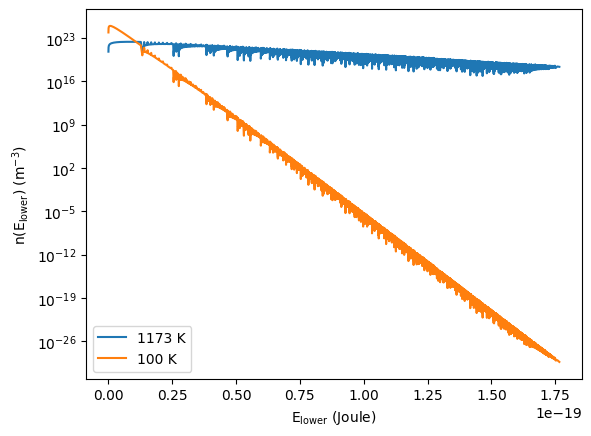

In [26]:
#%matplotlib widget
#Test of the density profiles (using data for WASP-39 b) 
z = 100
T_atm = 900 + 273
Mm = 44 # molar mass for CO2
P0 = 1e5  
#M_p = const.M_earth.value 
#R_p = const.R_earth.value 

#We retrieve these two from before (CO2)
energy_levels = E_J.value
degeneracies = levels_unique['g'].values
print(len(energy_levels))
print(len(degeneracies))

H_factor=2
H = scale_height(T_atm, Mm, M_p, R_p)*H_factor
print(H)

n_tot = density_profile_atm_consT(z, T_atm, H, P0)
Z = partition_function(energy_levels, degeneracies, T_atm)

T_2 = 100
n_2 = density_profile_atm_consT(z, T_2, H, P0)
Z_2 = partition_function(energy_levels, degeneracies, T_2)

n_levels=[]
n_2_tot = []

for i in range(len(energy_levels)):
    n_levels.append(energy_level_density(energy_levels[i],degeneracies[i],T_atm, Z, n_tot))
    n_2_tot.append(energy_level_density(energy_levels[i],degeneracies[i],T_2, Z_2, n_2))

plt.figure()
plt.plot(E_J, n_levels, label=f'{T_atm} K')
plt.plot(E_J, n_2_tot, label=f'{T_2} K')
plt.xlabel(r'E$_\mathrm{lower}$ (Joule)')
plt.ylabel(r'n(E$_\mathrm{lower}$) (m$^{-3}$)')
plt.yscale('log')
#plt.xlim(0, 0.25e-19)
plt.legend()
plt.show()

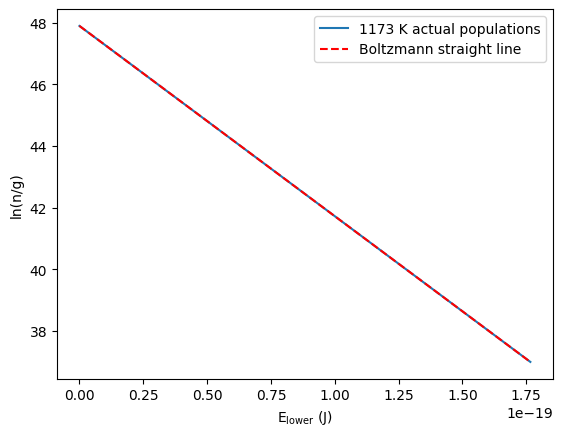

In [27]:
n_levels_over_degeneracy=[]
for i in range(len(energy_levels)):
    n_levels_over_degeneracy.append(energy_level_density(energy_levels[i],degeneracies[i],T_atm, Z, n_tot)/degeneracies[i])

straight_line = np.log(n_tot/Z) - energy_levels/(const.k_B.value * T_atm)

 
plt.figure()
plt.plot(E_J, np.log(np.array(n_levels_over_degeneracy)), label=f'{T_atm} K actual populations')
plt.plot(E_J, straight_line, 'r--',label='Boltzmann straight line')
plt.xlabel(r'E$_\mathrm{lower}$ (J)')
plt.ylabel(r'ln(n/g)')
plt.legend(loc="upper right")
plt.show()

#Straight line plot suggested by the professors. 
#From the Boltzann expression, if we are in Thermodynamic Equilibrium then:
# --> log(ni/gi) = log(ntot/Z) - Ei/k_BT
#Thefore: straigth line with slope m = -1/k_BT and intercept c = log(ntot/Z)

In [28]:
print(np.trapezoid(n_levels,x=E_J))
print(np.trapezoid(n_2_tot, x=E_J))

536.697165159465 J
26514.53935196795 J


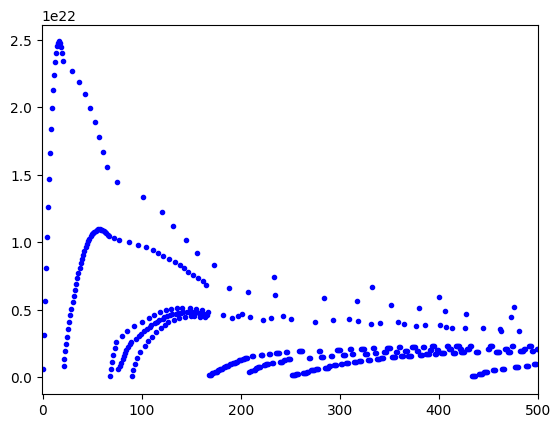

In [29]:
#Plotting the first levels (more populated)
#The beahaviour seem to be the expected, with spikes corresponding to high degeneracy levels
plt.figure()
plt.plot(n_levels, 'bo',markersize=3)
plt.xlim(-1,500)
plt.show()

## Computing tau (without collisional broadening) 

In [30]:
n_CO2 = []
zmax = 50*H # height at which we consider atmosphere to be 0
z = np.arange(0, zmax, 1e4)
for i in range(len(z)):
    n_z = density_profile_atm_consT(z[i], T_atm, H, P0)
    n_total_array = energy_level_density(energy_levels, degeneracies, T_atm, Z, n_z) 
    n_total = np.sum(n_total_array)
    n_CO2.append(n_total)


In [31]:
# total_absorption_sigma = sigma_new
# len(total_absorption_sigma)

In [32]:
n_CO2 = np.array(n_CO2)
delta_nu = []

for i in range(len(total_absorption_sigma)):
    T_nu = []
    for j in range(len(z)):
        tau_nu = total_absorption_sigma[i]*n_CO2[j]*np.sqrt(2*np.pi*(z[j] + R_p)*H) # trusting Lellouch slide 66
        T_nu.append(np.exp(-np.array(tau_nu)))
    T_nu = np.array(T_nu)
    R_eff2 = R_p**2 + 2 * np.trapezoid((1 - T_nu) * (z + R_p), z + R_p)
    delta_nu.append(R_eff2 / R_star**2)
print(len(delta_nu))

1000


In [33]:
def fast_binning(x, y, bins, error=None, std=False):
    bins = np.arange(np.min(x), np.max(x), bins)
    d = np.digitize(x, bins)

    n = np.max(d) + 2

    binned_x = np.empty(n)
    binned_y = np.empty(n)
    binned_error = np.empty(n)

    binned_x[:] = -np.pi
    binned_y[:] = -np.pi
    binned_error[:] = -np.pi

    for i in range(0, n):
        s = np.where(d == i)
        if len(s[0]) > 0:
            s = s[0]
            binned_y[i] = np.mean(y[s])
            binned_x[i] = np.mean(x[s])
            binned_error[i] = np.std(y[s]) / np.sqrt(len(s))

            if error is not None:
                err = error[s]
                binned_error[i] = np.sqrt(np.sum(np.power(err, 2))) / len(err)
            else:
                binned_error[i] = np.std(y[s]) / np.sqrt(len(s))

    nans = binned_x == -np.pi
    
    return binned_x[~nans], binned_y[~nans], binned_error[~nans]

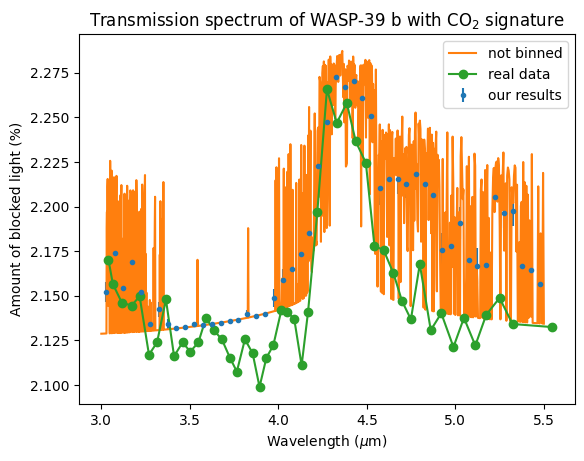

In [34]:
lambda_array = (const.c.value/freq_array)*1e6
y = np.array(delta_nu)*100
binned_data = fast_binning(lambda_array, y, 0.05)
observed_data = pd.read_csv('WASP39b_data.csv')
observed_x = observed_data.iloc[:,0]
observed_y = observed_data.iloc[:,1]

plt.figure()
plt.errorbar(binned_data[0], binned_data[1], binned_data[2], fmt='.', label='our results')
plt.plot(lambda_array, y, label='not binned')
plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()

t_full: 0.08090542927857325
t_total: 0.11710312232324338


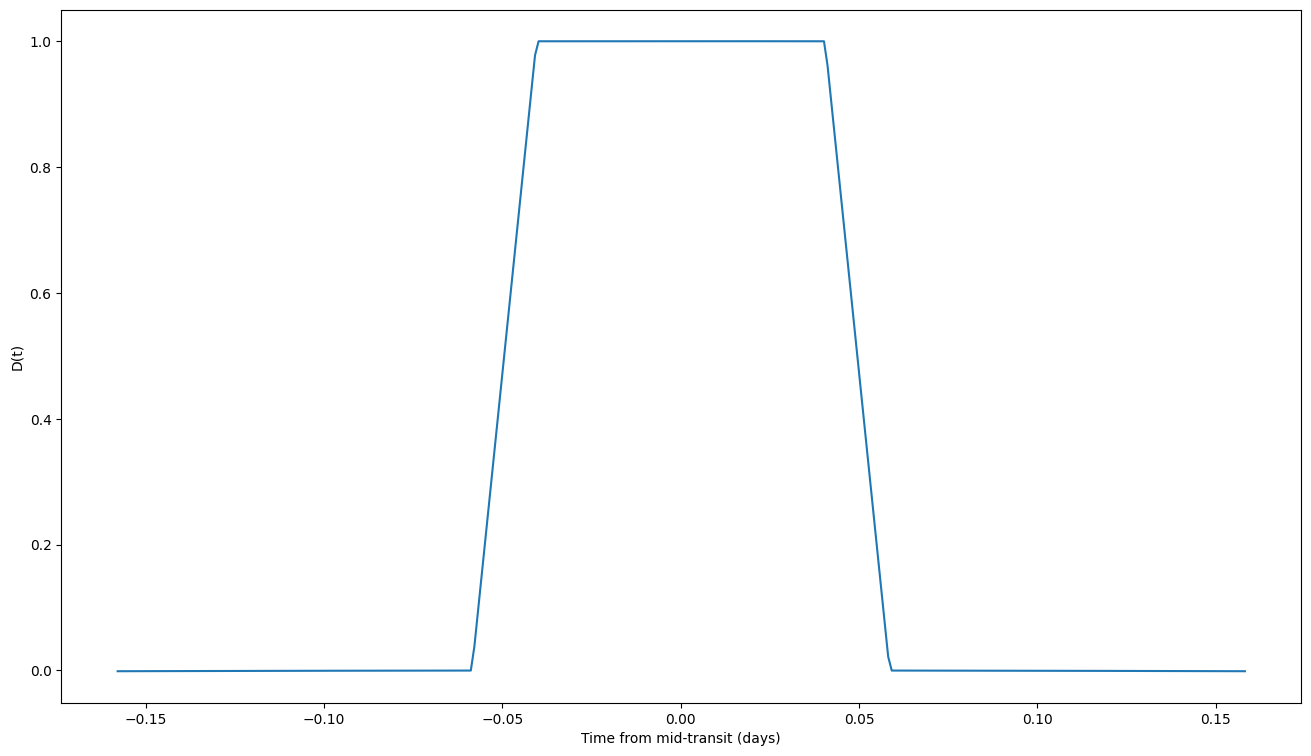

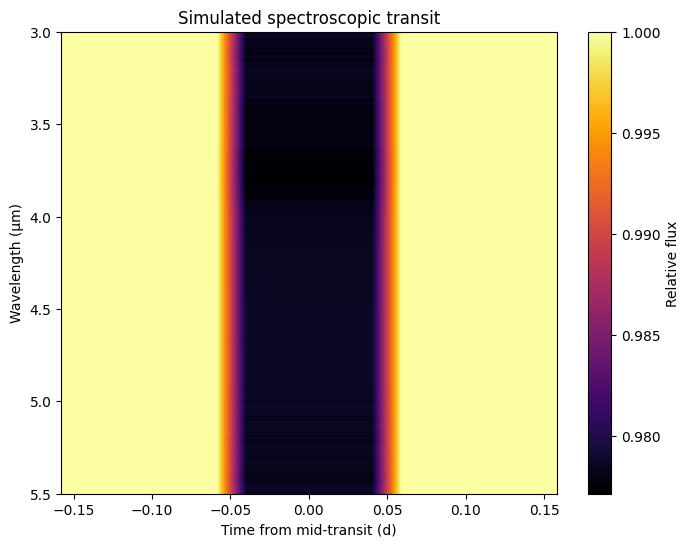

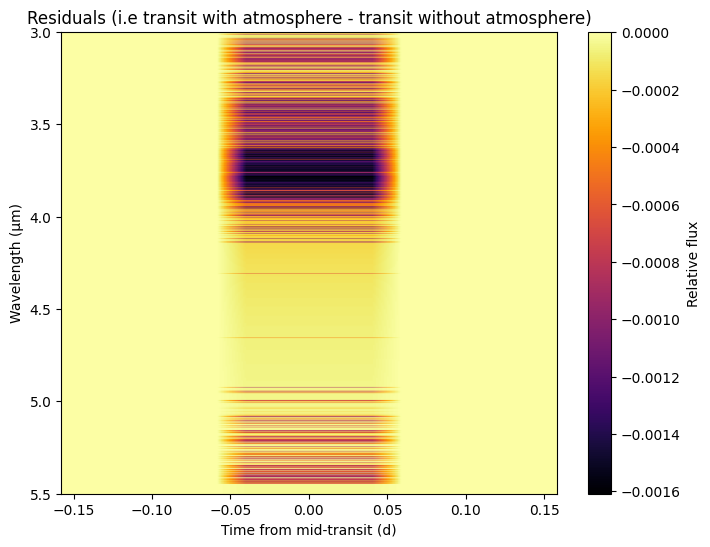

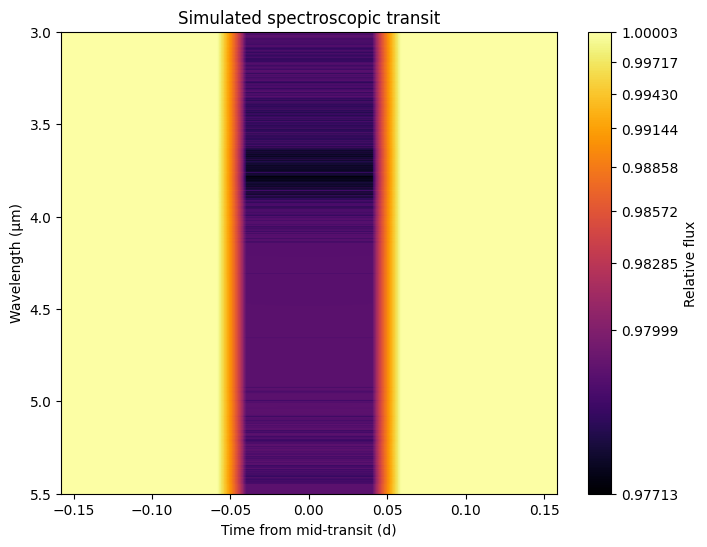

In [35]:
#Data for Wasp-39b 

e = 0.0
P = 4.055259
omega = 0.0 # bcs e = 0
i = 87.83*np.pi/180
a = 0.0486*149597870700 # a in m
R_star = 0.895*const.R_sun.value
T_star = 5400
T_planet = T_atm
flux_star = BlackBody(T_star*u.K)(5.96*u.micron)
flux_planet = BlackBody(T_planet*u.K)(5.96*u.micron)

#I redefine variables in case there were lost or redifined along the way

t_full = full_transit_duration(P, a, R_star, R, i, e, omega, b)
t_total = total_transit_duration(P, a, R_star, R, i, e, omega, b)

print("t_full:", t_full)
print("t_total:", t_total)


t_start = 0
t_end = 10 # simulation duration in days
nb_points = 10000 # number of points in the time array
t = np.linspace(t_start,t_end,nb_points) # time array in days


t_ingress_start = -t_total / 2 + P
t_ingress_end = -t_full / 2 + P
t_egress_start = t_full / 2 + P
t_egress_end = t_total / 2 + P
t_central = 0.5 * (t_egress_end + t_ingress_start)


#NOW THE NEW STUFF 

#Relative Flux will be something like: F(lambda, t) = 1 - D(t) * (y(lambda)/100)
#Where D(t) just tells us where we are in terms of the transit with respect to time.

#We recover this from cell 12 (smooth transit by Nisrine)
phase_curvee = phase_curve(flux_star,flux_planet,R_star,R,phase(t, P),eclipse_bool, transit_depth(R, R_star), transit_smooth(P, a, R_star, R, i, phase, e, omega, b, t, t_start))

#From here we can compute the D(t) that we were looking for (i.e. one that is 0 out of tranist and 1 in)
#I am sure there must be a better way using the functions that we already have, but this should work
#Also, I am focusing on a transit 

mask = (t >= t_ingress_start - 0.1) & (t <= t_egress_end + 0.1)
time_for_plot = t[mask]
phase_curvee_for_plot = phase_curvee[mask]

D_t = (1 - phase_curvee_for_plot) / transit_depth(R, R_star)
t_centered = time_for_plot - t_central #I do this to shift the plot so that the central time is at zero

#A plot just to check that D(t) behaves correctly 
plt.figure(figsize=(16,9))
plt.plot(t_centered, D_t)
plt.xlabel('Time from mid-transit (days)')
plt.ylabel('D(t)')
plt.show()


depth_lambda = y / 100.0 #y was computed in the previous cell        

#We compute the flux in terms of time and lambda
#For that, we use np.outer, which provides us a product for each time and each wavelength and stores in a 2D array
flux_time_lambda = 1 - np.outer(D_t, depth_lambda) 

#Plot:
plt.figure(figsize=(8,6))

plt.imshow(flux_time_lambda.T,
           extent=[t_centered.min(), t_centered.max(),lambda_array.max(), lambda_array.min()],
           aspect='auto',
           cmap='inferno')

plt.colorbar(label='Relative flux')
plt.xlabel('Time from mid-transit (d)')
plt.ylabel('Wavelength (µm)')
plt.title('Simulated spectroscopic transit')
plt.show()

#If we plot just this, the plot is dominated by the transit depth of the planet without the atmosphere. 
#So what I'll do is just subtract the transit depth that is not due to the atmosphere

flux_time_lambda_0 = 1 - transit_depth(R, R_star) * D_t 
residuals = flux_time_lambda - flux_time_lambda_0[:, None]

plt.figure(figsize=(8,6))

plt.imshow(residuals.T,
           extent=[t_centered.min(), t_centered.max(),lambda_array.max(), lambda_array.min()],
           aspect='auto',
           cmap='inferno')

plt.colorbar(label='Relative flux')
plt.xlabel('Time from mid-transit (d)')
plt.ylabel('Wavelength (µm)')
plt.title('Residuals (i.e transit with atmosphere - transit without atmosphere)')
plt.show()

#One more try without using the residuals:
from matplotlib.colors import PowerNorm
#We'll smothly strecht our colorbar so that it catches the small changes
#For exact documentation, see: https://matplotlib.org/stable/api/_as_gen/matplotlib.colors.PowerNorm.html

plt.figure(figsize=(8,6))
norm = PowerNorm(gamma=0.5,
                 vmin=flux_time_lambda.min(),
                 vmax=flux_time_lambda.max())

plt.imshow(flux_time_lambda.T,
           extent=[t_centered.min(), t_centered.max(),lambda_array.max(), lambda_array.min()],
           aspect='auto',
           cmap='inferno',
           norm=norm)

cbar = plt.colorbar(label='Relative flux', format='%.5f')
cbar.set_ticks(np.linspace(flux_time_lambda.min(),flux_time_lambda.max(), 9))

plt.xlabel('Time from mid-transit (d)')
plt.ylabel('Wavelength (µm)')
plt.title('Simulated spectroscopic transit')
plt.show()

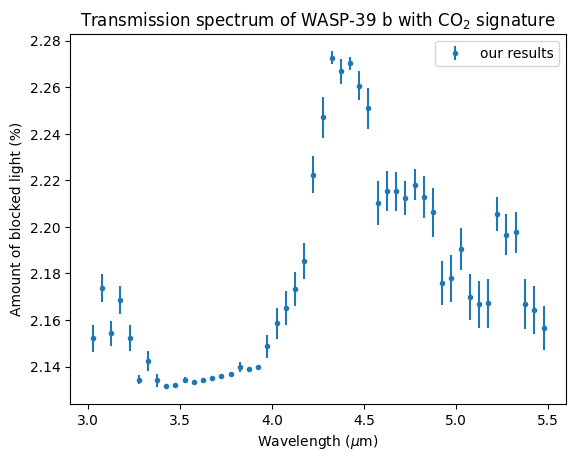

In [36]:
plt.figure()
plt.errorbar(binned_data[0], binned_data[1], binned_data[2], fmt='.', label='our results')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()

## Computing tau (with collisional broadening) 

In [37]:
"""n_CO2 = []
zmax = 50*H # height at which we consider atmosphere to be 0
z_array = np.linspace(0, zmax, num=50)
for i in range(len(z_array)):
    n_z = density_profile_atm_consT(z_array[i], T_atm, H, P0)
    n_CO2.append(sum(energy_level_density(energy_levels[j],degeneracies [j],T_atm, Z, n_z) for j in range(len(energy_levels))))

n_CO2 = np.array(n_CO2)
delta_nu_col = []

for i in range(len(freq_array)):
    
    T_nu_z = []

    for j, z in enumerate(z_array):

        sigma_zi = absorption_sigma_z[j, i] # now we have a height-dependent absorption sigma!!
        tau_zi = sigma_zi * n_CO2[j] * np.sqrt(2*np.pi*(z + R_p)*H) # trusting Lellouch slide 66
        T_nu_z.append(np.exp(-tau_zi))                # transmission

    T_nu_z = np.array(T_nu_z)
    R_eff2 = R_p**2 + 2 * np.trapezoid((1 - T_nu_z) * (z_array + R_p), z_array + R_p)
    delta_nu_col.append(R_eff2 / R_star**2)"""
 

'n_CO2 = []\nzmax = 50*H # height at which we consider atmosphere to be 0\nz_array = np.linspace(0, zmax, num=50)\nfor i in range(len(z_array)):\n    n_z = density_profile_atm_consT(z_array[i], T_atm, H, P0)\n    n_CO2.append(sum(energy_level_density(energy_levels[j],degeneracies [j],T_atm, Z, n_z) for j in range(len(energy_levels))))\n\nn_CO2 = np.array(n_CO2)\ndelta_nu_col = []\n\nfor i in range(len(freq_array)):\n\n    T_nu_z = []\n\n    for j, z in enumerate(z_array):\n\n        sigma_zi = absorption_sigma_z[j, i] # now we have a height-dependent absorption sigma!!\n        tau_zi = sigma_zi * n_CO2[j] * np.sqrt(2*np.pi*(z + R_p)*H) # trusting Lellouch slide 66\n        T_nu_z.append(np.exp(-tau_zi))                # transmission\n\n    T_nu_z = np.array(T_nu_z)\n    R_eff2 = R_p**2 + 2 * np.trapezoid((1 - T_nu_z) * (z_array + R_p), z_array + R_p)\n    delta_nu_col.append(R_eff2 / R_star**2)'

In [38]:
"""lambda_array = (const.c.value/freq_array)*1e6
y = np.array(delta_nu_col)*100
binned_data = fast_binning(lambda_array, y, 0.1)
observed_data = pd.read_csv('WASP39b_data.csv')
observed_x = observed_data.iloc[:,0]
observed_y = observed_data.iloc[:,1]

plt.figure()
plt.errorbar(binned_data[0], binned_data[1], binned_data[2], fmt='.', label='our results')
plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()"""

"lambda_array = (const.c.value/freq_array)*1e6\ny = np.array(delta_nu_col)*100\nbinned_data = fast_binning(lambda_array, y, 0.1)\nobserved_data = pd.read_csv('WASP39b_data.csv')\nobserved_x = observed_data.iloc[:,0]\nobserved_y = observed_data.iloc[:,1]\n\nplt.figure()\nplt.errorbar(binned_data[0], binned_data[1], binned_data[2], fmt='.', label='our results')\nplt.plot(observed_x, observed_y, 'o-', label='real data')\nplt.xlabel(r'Wavelength ($\\mu$m)')\nplt.ylabel('Amount of blocked light (%)')\nplt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')\nplt.legend()\nplt.show()"

### ADDING SPECIES ###

In [39]:
### Adding Species Here
species = {
    'H2O': {'mol_id': 1, 'iso_id': 1, 'fraction': 0.004, 'mu': 18},
    'CO2': {'mol_id': 2, 'iso_id': 1, 'fraction': 1e-3, 'mu': 44},
    'CO':  {'mol_id': 5, 'iso_id': 1, 'fraction': 1e-4, 'mu': 28},
    'SO2': {'mol_id': 9, 'iso_id': 1, 'fraction': 1e-5, 'mu': 64},
    #'H2S': {'mol_id': 31, 'iso_id': 1, 'fraction': 1e-6, 'mu': 34},
    #'CH4': {'mol_id': 6, 'iso_id': 1, 'fraction': 1e-12, 'mu': 16},
    # Hydrogen and Helium have very weak lines
    'H2': {'mol_id': 45, 'iso_id': 1, 'fraction': 0.85, 'mu': 2},   # Hydrogen
}


In [40]:
"""H2_CO2 = 4
species = {
    #'H2O': {'mol_id': 1, 'iso_id': 1, 'fraction': 1e-3, 'mu': 18},
    'CO2': {'mol_id': 2, 'iso_id': 1, 'fraction': 4/14, 'mu': 44},
    #'CO':  {'mol_id': 5, 'iso_id': 1, 'fraction': 0.15, 'mu': 28},
    #'SO2': {'mol_id': 9, 'iso_id': 1, 'fraction': 1e-3, 'mu': 64},
    #'H2S': {'mol_id': 31, 'iso_id': 1, 'fraction': 1e-6, 'mu': 34},
    #'CH4': {'mol_id': 6, 'iso_id': 1, 'fraction': 1e-12, 'mu': 16},
    # Hydrogen and Helium have very weak lines
    'H2': {'mol_id': 45, 'iso_id': 1, 'fraction': 1, 'mu': 2},   # Hydrogen
}"""

"H2_CO2 = 4\nspecies = {\n    #'H2O': {'mol_id': 1, 'iso_id': 1, 'fraction': 1e-3, 'mu': 18},\n    'CO2': {'mol_id': 2, 'iso_id': 1, 'fraction': 4/14, 'mu': 44},\n    #'CO':  {'mol_id': 5, 'iso_id': 1, 'fraction': 0.15, 'mu': 28},\n    #'SO2': {'mol_id': 9, 'iso_id': 1, 'fraction': 1e-3, 'mu': 64},\n    #'H2S': {'mol_id': 31, 'iso_id': 1, 'fraction': 1e-6, 'mu': 34},\n    #'CH4': {'mol_id': 6, 'iso_id': 1, 'fraction': 1e-12, 'mu': 16},\n    # Hydrogen and Helium have very weak lines\n    'H2': {'mol_id': 45, 'iso_id': 1, 'fraction': 1, 'mu': 2},   # Hydrogen\n}"

In [41]:
T_atm = 900 + 273        
P0 = 1e5  

Mm_mean = 2.3


H = scale_height(T_atm, Mm_mean, M_p, R_p) 
zmax = 20*H
z_array = np.arange(0, zmax, 1e3) 
z = z_array


In [42]:
def new_voigt_profile(sigma, delta, center, frequency):
    # Reshape for broadcasting: center and delta along axis 0, frequency along axis 1
    z = ((frequency[None, :] - center[:, None]) + 1j * delta[:, None]) / (sigma[:, None] * np.sqrt(2))
    return np.real(wofz(z)) / (sigma[:, None] * np.sqrt(2 * np.pi))

def pressure(z, H):
    P = P0*np.exp(-z/H)
    return P 

In [43]:
##NEW CELL INCLUDING BROADENING




db_begin('hitran_db_all')

freq_array = np.linspace(const.c.value/(5.5e-6), const.c.value/(0.5e-6), 1000)

T_atm = 900 + 273
Nz = 50

Mm_bulk = 2.3
H_bulk = scale_height(T_atm, Mm_bulk, M_p, R_p)
zmax = 10*H_bulk
z_array = np.linspace(0, zmax, Nz)

sigma_total = np.zeros((Nz, len(freq_array)))

for sp, params in species.items():
    print("Control print: new species")
    
    mu = params['mu']
    f_sp = params['fraction']
    table_name = f"{sp}_4um"

    
    nu_cm, A_vals, elower_cm, g_u, g_l = getColumns(table_name, ['nu', 'A', 'elower', 'gp', 'gpp'])
    df = pd.DataFrame({'nu': nu_cm, 
                       'A': A_vals, 
                       'elower': elower_cm, 
                       'gp': g_u, 
                       'gpp': g_l})

    
    #For tau (natural broadening)
    df['E_u'] = df['elower'] + df['nu']  
    A_sum_by_Eu = df.groupby('E_u')['A'].sum()
    tau_u = 1 / A_sum_by_Eu
    tau_df = tau_u.reset_index()
    tau_df.columns = ['E_u', 'tau_u']
    df = df.merge(tau_df, on='E_u', how='left')
    
    tau_lorentz = (df['tau_u'].values*(u.s)).value
    nu_array = np.array(nu_cm)  # removes mask
    nu_lines = (nu_array * u.cm**-1).to(u.Hz, equivalencies=u.spectral()).value

    
    #For the collisional broadening: 
    collision_columns = ['nu','gamma_air', 'gamma_self', 'n_air']
    collision_data = getColumns(table_name, collision_columns)
    df_collision = pd.DataFrame({col: collision_data[i] for i, col in enumerate(collision_columns)})  
    
    
    # Scale height for species
    H_sp = scale_height(T_atm, mu, M_p, R_p)
    sigma_sp = np.zeros((Nz, len(freq_array)))

    # Precompute line constants
    gp = g_u
    gpp = g_l
    prefactor = (gp / gpp) * (const.c.value**2 / (8*np.pi*nu_lines**2)) * A_vals
    
   
    # Thermal + microturbulence velocity
    v_th = np.sqrt(const.k_B.value * T_atm / (mu / (1000 * const.N_A.value)))
    xi = 2e3
    v_D = np.sqrt(2*v_th**2 + 2*xi**2)
    sigma_D = (nu_lines / const.c.value) * v_D
    natural_delta = 1/(4*np.pi*tau_lorentz)

    # Vectorized over altitude
    for j, z in enumerate(z_array):
        print("Control print: height")
        P_sp = pressure(z, H_sp)/101325

        collision_delta = (const.c.value*100*(296/T_atm)**df_collision['n_air'].values) * (df_collision['gamma_self'].values*P_sp)
        delta_L = natural_delta + collision_delta

        # Vectorized Voigt profile for all lines at once
        profile = new_voigt_profile(sigma_D, delta_L, nu_lines, freq_array)
        sigma_layer = np.sum(prefactor[:,None] * profile, axis=0)
        sigma_sp[j,:] = sigma_layer

    # Store per-species and add to total
    sigma_total += f_sp * sigma_sp
    params['absorption_sigma_z'] = sigma_sp

Using hitran_db_all

He_4um
                     Lines parsed: 36286
CH4_4um
                     Lines parsed: 232660
CO2_4um
                     Lines parsed: 137970
SO2_4um
                     Lines parsed: 113303
H2_4um
                     Lines parsed: 4048
H2S_4um
                     Lines parsed: 77233
CO_4um
                     Lines parsed: 1024
H2O_4um
                     Lines parsed: 214686
Control print: new species
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control print: height
Control pri

/tmp/ipykernel_30655/2873637111.py:12: RuntimeWarning: divide by zero encountered in divide
  return const.c.value / (l*1e-6)


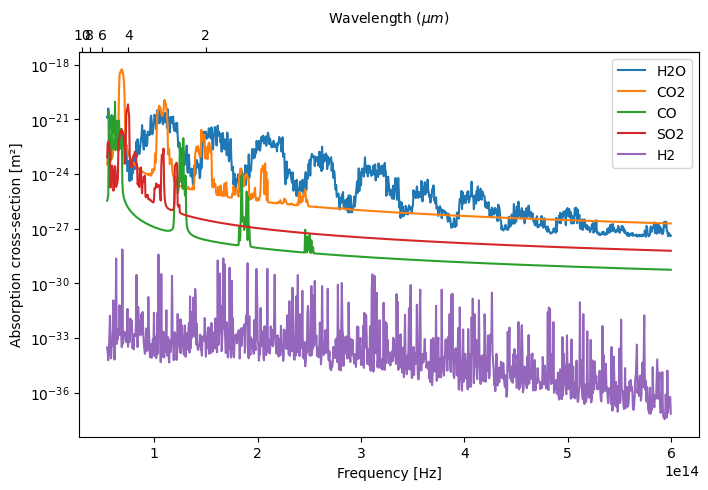

In [50]:
fig, ax1 = plt.subplots(figsize=(8,5))
for sp in species.keys():
    ax1.plot(freq_array, species[sp]['absorption_sigma_z'][0,:], label=sp)
ax1.set_yscale('log')
ax1.set_xlabel('Frequency [Hz]')
ax1.set_ylabel('Absorption cross-section [m²]')
ax1.legend()

def freq_to_wavelength_um(f):
    return const.c.value / f * 1e6
def wavelength_um_to_freq(l):
    return const.c.value / (l*1e-6)

ax2 = ax1.secondary_xaxis('top', functions=(freq_to_wavelength_um, wavelength_um_to_freq))
ax2.set_xlabel(r'Wavelength ($\mu m$)')
plt.show()

In [47]:

"""Mm_bulk = 0
for sp, params in species.items():
    mu_sp = params['mu']        
    f_sp = params['fraction']
    Mm_bulk += (f_sp * mu_sp)

print(Mm_bulk)"""
"""H_factor = 2
H = scale_height(T_atm, Mm_bulk, M_p, R_p)*2
print(H)
try:
    n_tot = density_profile_atm_consT(z, T_atm, H, P0)
except Exception:
    density_vec = np.vectorize(lambda zz: density_profile_atm_consT(zz, T_atm, H, P0))
    n_tot = density_vec(z)"""


'H_factor = 2\nH = scale_height(T_atm, Mm_bulk, M_p, R_p)*2\nprint(H)\ntry:\n    n_tot = density_profile_atm_consT(z, T_atm, H, P0)\nexcept Exception:\n    density_vec = np.vectorize(lambda zz: density_profile_atm_consT(zz, T_atm, H, P0))\n    n_tot = density_vec(z)'

Calculating Density profile for H2O...
H2O
978339.384383754
Calculating Density profile for CO2...
CO2
978339.384383754
Calculating Density profile for CO...
CO
978339.384383754
Calculating Density profile for SO2...
SO2
978339.384383754
Calculating Density profile for H2...
H2
978339.384383754


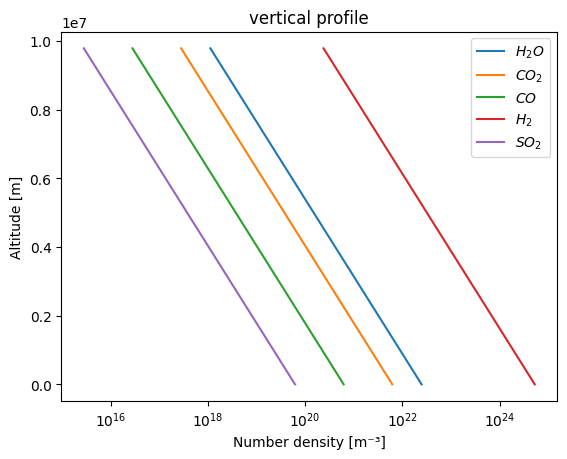

In [56]:
"""if sp == 'H2' or energy_levels is None or len(energy_levels) == 0:
        # If we don't have energy levels (H2 here), use mixing ratio * total number density
        print(f"Using mixing ratio for {sp} (no level data).")
        params['n_profile'] = f_sp * n_tot
        continue"""
# --------------- STEP 5 : Density profile for each species n_i (z) ----------
"""Mm_H2 = species['H2']['mu']
H = scale_height(T_atm, Mm_H2, M_p, R_p)"""
T_atm = 900 + 273        
P0 = 1e5  
Mm_mean = 2.3
H = scale_height(T_atm, Mm_mean, M_p, R_p) 
z = z_array




for sp, params in species.items():
    print(f"Calculating Density profile for {sp}...")
    energy_levels = params.get('energy_levels')
    Mm = params['mu']        
    f_sp = params['fraction']
    print(sp)
    #if sp=='H2' or sp=='H2O':
    H = scale_height(T_atm, Mm_mean, M_p, R_p)
        #print(H)
    #else:
    #    H = scale_height(T_atm, Mm, M_p, R_p)*H_factor
    print(H)
    #n_tot = density_profile_atm_consT(z_i, T_atm, H, P0)

    #energy_levels = np.array(params['energy_levels'])
    degeneracies = np.array(params['degeneracies'])

    n_species = []
    
    #zmax = 5*H
    #z = np.arange(0, zmax, 1e3) 
    for i, z_i in enumerate(z):    
        
        n_z = density_profile_atm_consT(z_i, T_atm, H, P0, fraction=1)
        #constant=2e-4
        #n_z = density_profile_atm_linearT(z_i, T_atm, Mm, M_p, R_p, P0, constant)
        # n_z = n_tot[i]
        # vectorize this... 
        n_total_array = energy_level_density(energy_levels, degeneracies, T_atm, params['partition_function'], n_z) 
        # n_total = sum(energy_level_density(energy_levels[j], degeneracies[j], T_atm, params['partition_function'], n_z) for j in range(len(energy_levels)))
        n_total = np.sum(n_total_array)
        #if i == 0:
        n_total *= f_sp
        n_species.append(n_total)

        
    params['n_profile'] = np.array(n_species)
    
# CHECK  dict_keys(['H2O', 'CO2', 'CO', 'CH4', 'H2S'])
plt.figure()
plt.plot(species['H2O']['n_profile'], z, label = r'$H_2O$')
plt.plot(species['CO2']['n_profile'], z, label = r'$CO_2$')
plt.plot(species['CO']['n_profile'], z, label = r'$CO$')
#plt.plot(species['CH4']['n_profile'], z, label = r'$CH_4$')
#plt.plot(species['H2S']['n_profile'], z, label = r'$H2S$')
plt.plot(species['H2']['n_profile'], z, label = r'$H_2$')
plt.plot(species['SO2']['n_profile'], z, label = r'$SO_2$')


plt.gca().invert_yaxis()
plt.xlabel('Number density [m⁻³]')
plt.ylabel('Altitude [m]')
plt.xscale('log')
plt.gca().invert_yaxis() 
plt.title(f'vertical profile')
plt.legend()
plt.show()


In [57]:
Nz = len(z_array)
Nnu = next(iter(species.values()))['absorption_sigma_z'].shape[1]

# Transit depths per species
delta_nu_species = {}

# Total optical depth summed over species
tau_total = np.zeros((Nz, Nnu))


for sp, params in species.items():

    print(f"Computing transit depth for {sp}...")

    n_profile = np.asarray(params['n_profile'])                  # (Nz,)
    absorption_sigma_z = np.asarray(params['absorption_sigma_z'])# (Nz, Nnu)

    tau = np.zeros((Nz, Nnu))

    for k, z0 in enumerate(z_array):

        mask = z_array >= z0
        z_segment = z_array[mask]

        ds_dz = (R_p + z_segment) / np.sqrt((R_p + z_segment)**2 - (R_p + z0)**2)
        ds_dz[0] = 0.0   #to avoid singularity

        integrand = (n_profile[mask, None] * absorption_sigma_z[mask, :] * ds_dz[:, None])

        tau[k, :] = 2.0 * np.trapezoid(integrand, z_segment, axis=0)

    
    tau_total += tau
    delta_nu = np.zeros(Nnu)

    for i in range(Nnu):

        T_nu_z = np.exp(-tau[:, i])   
        integrand = (1.0 - T_nu_z) * (z_array + R_p)

        R_eff2 = R_p**2 + 2.0 * np.trapezoid(integrand, z_array)
        delta_nu[i] = R_eff2 / R_star**2

    delta_nu_species[sp] = delta_nu

        
delta_nu_total = np.zeros(Nnu)

for i in range(Nnu):

    T_nu_z = np.exp(-tau_total[:, i])
    integrand = (1.0 - T_nu_z) * (z_array + R_p)

    R_eff2 = R_p**2 + 2.0 * np.trapezoid(integrand, z_array)
    delta_nu_total[i] = R_eff2 / R_star**2


Computing transit depth for H2O...
Computing transit depth for CO2...
Computing transit depth for CO...
Computing transit depth for SO2...
Computing transit depth for H2...


/tmp/ipykernel_30655/239838704.py:31: RuntimeWarning: divide by zero encountered in divide
  ds_dz = (R_p + z_segment) / np.sqrt((R_p + z_segment)**2 - (R_p + z0)**2)


In [58]:
freq_array = np.linspace(const.c.value/(5.5e-6), const.c.value/(0.5e-6), 1000)
lambda_array = (const.c.value/freq_array)*1e6

observed_data = pd.read_csv('WASP39b_data.csv')
observed_x = observed_data.iloc[:, 0]
observed_y = observed_data.iloc[:, 1]

observed_data_2 = pd.read_csv('WASP39b_data_extended.csv')
observed_x_2 = observed_data_2.iloc[:, 0]
observed_y_2 = observed_data_2.iloc[:, 1]

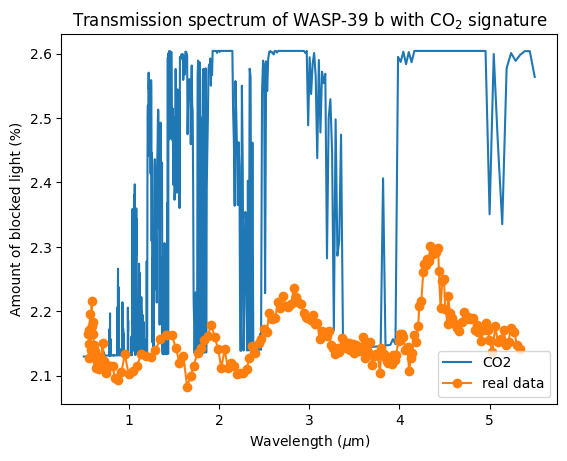

In [59]:
plt.figure()

for sp, delta in delta_nu_species.items():
    if sp == 'CO2':
        plt.plot(lambda_array, np.array(delta) * 100, label=sp)

plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')

plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with CO$_2$ signature')
plt.legend()
plt.show()


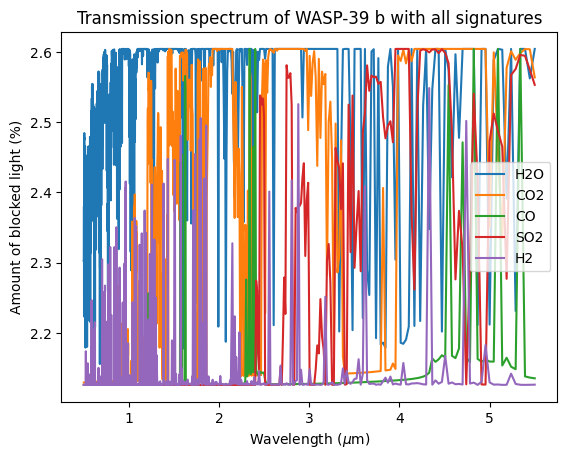

In [60]:
plt.figure()

for sp, delta in delta_nu_species.items():
    y_mix = np.array(delta) * 100
    plt.plot(lambda_array, y_mix, label=sp)

plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b with all signatures')
plt.legend()
plt.show()


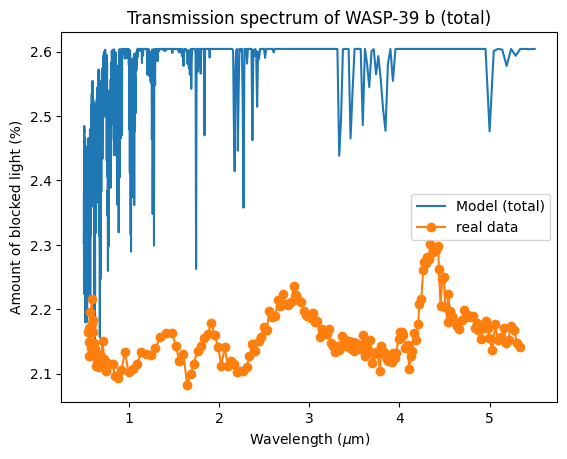

In [62]:
plt.figure()

plt.plot(lambda_array, np.array(delta_nu_total) * 100,
         label='Model (total)')

plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')

plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(r'Transmission spectrum of WASP-39 b (total)')
plt.legend()
plt.show()


### WARNING : THE PART BELOW IS NOT UP TO DATE ###

In [ ]:
def plot_spectrum(species, R_p=1.27*const.R_jup.value, H_factor=2, f_CO2=0.15, f_CO=0.15, f_H2O=1e-6, f_SO2=1e-3):
    species['CO2']['fraction'] = f_CO2
    if 'CO' in species:
        species['CO']['fraction'] = f_CO

    if 'H2O' in species:
        species['H2O']['fraction'] = f_H2O

    if 'SO2' in species:
        species['SO2']['fraction'] = f_SO2
    for sp, params in species.items():
        print(f"Calculating Density profile for {sp}...")
        energy_levels = params.get('energy_levels')
        Mm = params['mu']        
        f_sp = params['fraction']
        if sp=='H2O':
            H = scale_height(T_atm, Mm, M_p, R_p)
        else:
            H = scale_height(T_atm, Mm, M_p, R_p)*H_factor
        #n_tot = density_profile_atm_consT(z_i, T_atm, H, P0)

        #energy_levels = np.array(params['energy_levels'])
        degeneracies = np.array(params['degeneracies'])

        n_species = []
        
        for i, z_i in enumerate(z):    
            
            n_z = density_profile_atm_consT(z_i, T_atm, H, P0)
            #constant=2e-4
            #n_z = density_profile_atm_linearT(z_i, T_atm, Mm, M_p, R_p, P0, constant)
            # n_z = n_tot[i]
            # vectorize this... 
            n_total_array = energy_level_density(energy_levels, degeneracies, T_atm, params['partition_function'], n_z) 
            # n_total = sum(energy_level_density(energy_levels[j], degeneracies[j], T_atm, params['partition_function'], n_z) for j in range(len(energy_levels)))
            n_total = np.sum(n_total_array)
            n_total *= f_sp
            n_species.append(n_total)

        
        params['n_profile'] = np.array(n_species)
    # ---------- Setup ----------
    delta_nu_total = np.zeros_like(total_absorption_sigma)  # final transit depth array
    # Loop over species
    delta_nu_species = {}

    tau_total = 0

    for sp, params in species.items():
        # if sp == 'H2':
        #     print(f"Skipping for {sp}...")
        #     continue
        print(f"Calculating transit depth from {sp}...")

        n_profile = params['n_profile']             # number density as function of z
        sigma_profile = params['absorption_sigma']  # absorption cross-section for each freq

        assert len(n_profile) == len(z)
        #assert len(sigma_profile) == len(total_absorption_sigma)

        Mm = params['mu']  
        
        if sp=='H2O':
            H = scale_height(T_atm, Mm, M_p, R_p)
        else:
            H = scale_height(T_atm, Mm, M_p, R_p)*H_factor 
        tau = sigma_profile[:, None] * n_profile[None, :] * np.sqrt(2 * np.pi * (z + R_p) * H)  # shape (Nnu, Nz)
        tau_total += sigma_profile[:, None] * n_profile[None, :] * np.sqrt(2 * np.pi * (z + R_p) * H) 

        # Transmission
        T_nu = np.exp(-tau)  # shape (Nnu, Nz)
        

        # Compute R_eff^2 for each frequency
        integrand = (1 - T_nu) * (z + R_p)  # shape (Nnu, Nz)
        
        R_eff2 = R_p**2 + 2 * np.trapezoid(integrand, z + R_p, axis=1)  # shape (Nnu,)
        
        # Transit depth
        delta_nu_sp = R_eff2 / R_star**2
        delta_nu_species[sp] = delta_nu_sp

        if sp == 'CO2':
            delta_nu_CO2 = np.array(delta_nu_sp)
        
        #delta_nu_total += delta_nu_sp

    T_nu_total = np.exp(-tau_total)
    integrand_total = (1 - T_nu_total) * (z + R_p)
    R_eff2_total = R_p**2 + 2 * np.trapezoid(integrand_total, z + R_p, axis=1)
    delta_nu_total = R_eff2_total / R_star**2
    return (species, delta_nu_species, delta_nu_total)



In [ ]:
CO2_only = species_refined.copy()
CO2_only.pop('H2O')
CO2_only.pop('CO')
CO2_only.pop('SO2')

In [ ]:
no_CO = species_refined.copy()
no_CO.pop('CO')

In [ ]:

freq_array = np.linspace(const.c.value/(5.5e-6), const.c.value/(0.5e-6), 1000)
lambda_array = (const.c.value/freq_array)*1e6

data = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value)
data2 = plot_spectrum(CO2_only, R_p=1.26*const.R_jup.value)
plt.figure()
for sp, delta in data[1].items():
    y_mix = np.array(delta)*100
    f_sp = data[0][sp]['fraction']
    binned_data_mix = fast_binning(lambda_array, y_mix, 0.2)
    
    plt.plot(lambda_array, y_mix, label=f'{sp} {f_sp}')
    #plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label=f'{sp}')

# plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label='mixed')
#plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'H factor = 2')
plt.legend()
plt.show()

plt.figure()
plt.plot(lambda_array, np.array(data[2])*100, label='CO2 + H2O + SO2')
plt.plot(lambda_array, np.array(data2[2])*100, label='CO2')
plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'H factor = 2')
plt.legend()
plt.show()
    

In [ ]:
data = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=1)
data2 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=2)
data3 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=3)
#data2 = plot_spectrum(CO2_only, R_p=1.26*const.R_jup.value)
plt.figure()
for sp, delta in data[1].items():
    y_mix = np.array(delta)*100
    f_sp = data[0][sp]['fraction']
    binned_data_mix = fast_binning(lambda_array, y_mix, 0.2)
    
    plt.plot(lambda_array, y_mix, label=f'{sp} {f_sp}')
    #plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label=f'{sp}')

# plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label='mixed')
#plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'CO2 + H2O + SO2')
plt.legend()
plt.show()

plt.figure()
plt.plot(lambda_array, np.array(data[2])*100, label='H factor = 1', zorder=3)
plt.plot(lambda_array, np.array(data2[2])*100, label='H factor = 2', zorder=2)
plt.plot(lambda_array, np.array(data3[2])*100, label='H factor = 3', zorder=1)
plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'CO2 + H2O + SO2')
plt.legend()
plt.show()
    

In [ ]:
data = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=1)
data2 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=1, f_CO2 = 1)
#data3 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=3)
#data2 = plot_spectrum(CO2_only, R_p=1.26*const.R_jup.value)
plt.figure()
for sp, delta in data[1].items():
    y_mix = np.array(delta)*100
    f_sp = data[0][sp]['fraction']
    binned_data_mix = fast_binning(lambda_array, y_mix, 0.2)
    
    plt.plot(lambda_array, y_mix, label=f'{sp} {f_sp}')
    #plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label=f'{sp}')

# plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label='mixed')
#plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'H factor = 1')
plt.legend()
plt.show()

plt.figure()
plt.plot(lambda_array, np.array(data[2])*100, label='f_CO2 = 0.15', zorder=3)
plt.plot(lambda_array, np.array(data2[2])*100, label='f_CO2 = 1')
#plt.plot(lambda_array, np.array(data3[2])*100, label='H factor = 3')
plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'H factor = 1')
plt.legend()
plt.show()

In [ ]:
data = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=1, f_H2O=0)
data2 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=2, f_H2O=0)
data3 = plot_spectrum(no_CO, R_p=1.26*const.R_jup.value, H_factor=3, f_H2O=0)
#data2 = plot_spectrum(CO2_only, R_p=1.26*const.R_jup.value)
plt.figure()
for sp, delta in data[1].items():
    y_mix = np.array(delta)*100
    f_sp = data[0][sp]['fraction']
    binned_data_mix = fast_binning(lambda_array, y_mix, 0.2)
    
    plt.plot(lambda_array, y_mix, label=f'{sp} {f_sp}')
    #plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label=f'{sp}')

# plt.errorbar(binned_data_mix[0], binned_data_mix[1], binned_data_mix[2], fmt='.', label='mixed')
#plt.plot(observed_x, observed_y, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'CO2 + SO2')
plt.legend()
plt.show()

plt.figure()
plt.plot(lambda_array, np.array(data[2])*100, label='H factor = 1')
plt.plot(lambda_array, np.array(data2[2])*100, label='H factor = 2')
plt.plot(lambda_array, np.array(data3[2])*100, label='H factor = 3')
plt.plot(observed_x_2, observed_y_2, 'o-', label='real data')
plt.xlabel(r'Wavelength ($\mu$m)')
plt.ylabel('Amount of blocked light (%)')
plt.title(rf'CO2 + SO2')
plt.legend()
plt.show()